In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [30]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [4]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [5]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
G_hi = 20.5
G_lo = 20.0

In [8]:
nthreads = 18

In [9]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [10]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [11]:
mask_type = 'selfunc'

# Visuals

In [12]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [13]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [14]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [15]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [16]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

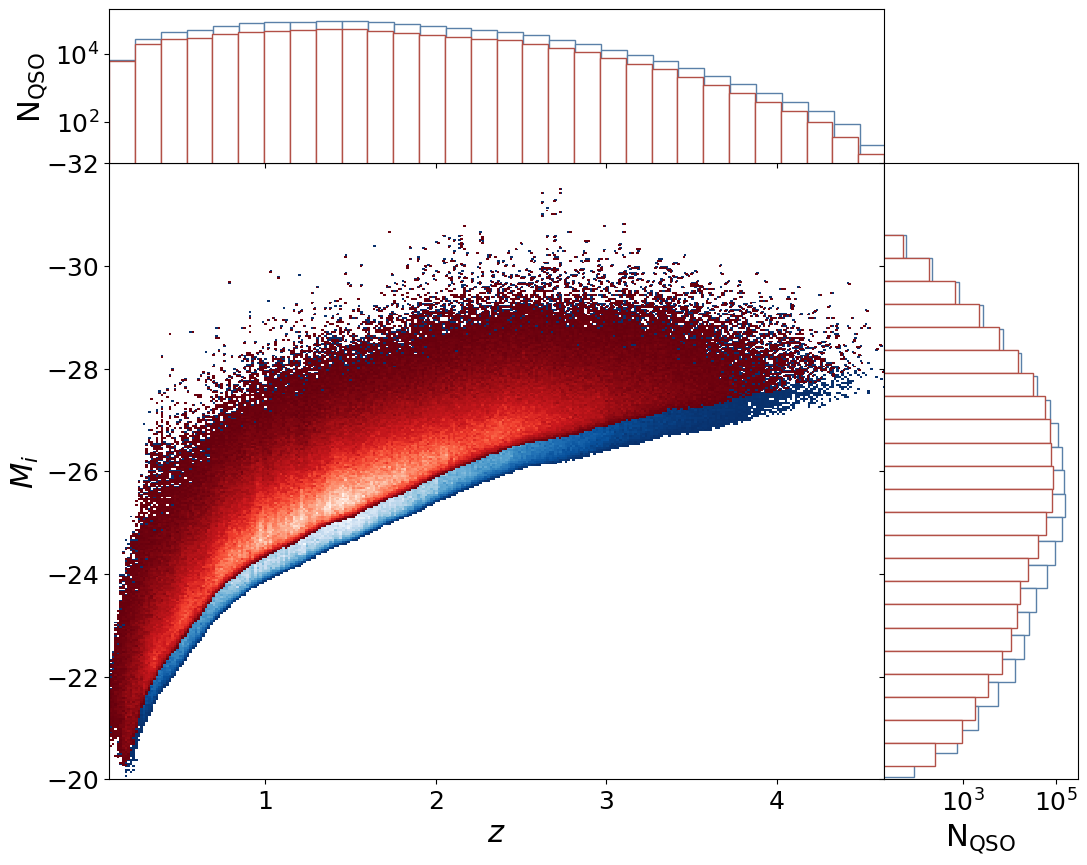

In [17]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in joint L z bins

In [46]:
L_bins = [-32.0, -27.0, -26.0, -25.0, -20.0]
z_bins = [0.0, 1.0, 2.0, 3.0, 4.6]
L_array = range(len(L_bins)-1)
z_array = range(len(z_bins)-1)
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [20.0, 20.5]
L_labels = ['${}<M_i\leq{}$'.format(L_bins[L], L_bins[L+1]) for L in range(len(L_bins[:-1]))]
z_labels = ['${}<z\leq{}$'.format(z_bins[L], z_bins[L+1]) for L in range(len(z_bins[:-1]))]

In [19]:
import importlib
importlib.reload(quaia)

<module 'quaia' from '/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py'>

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.00              1730 vs 1730
G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.00              9911 vs 9911
G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.01              38900 vs 39167
G20.0_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.43              84985 vs 149969
G20.0_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.00              36305 vs 36311
G20.0_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0: 0.07              124034 vs 132662
G20.0_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0: 0.43              99299 vs 173186
G20.0_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0: 0.49              13800 vs 27165
G20.0_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0: 0.11              84624 vs 95423
G20.0_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0: 0.65              24570 vs 69636
G20.0_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0: 0.00              211 vs 211
G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0: 0.06              19140 vs 20368
G20.0_zmin3.0zmax4.6_Lmin-27.0Lmax-

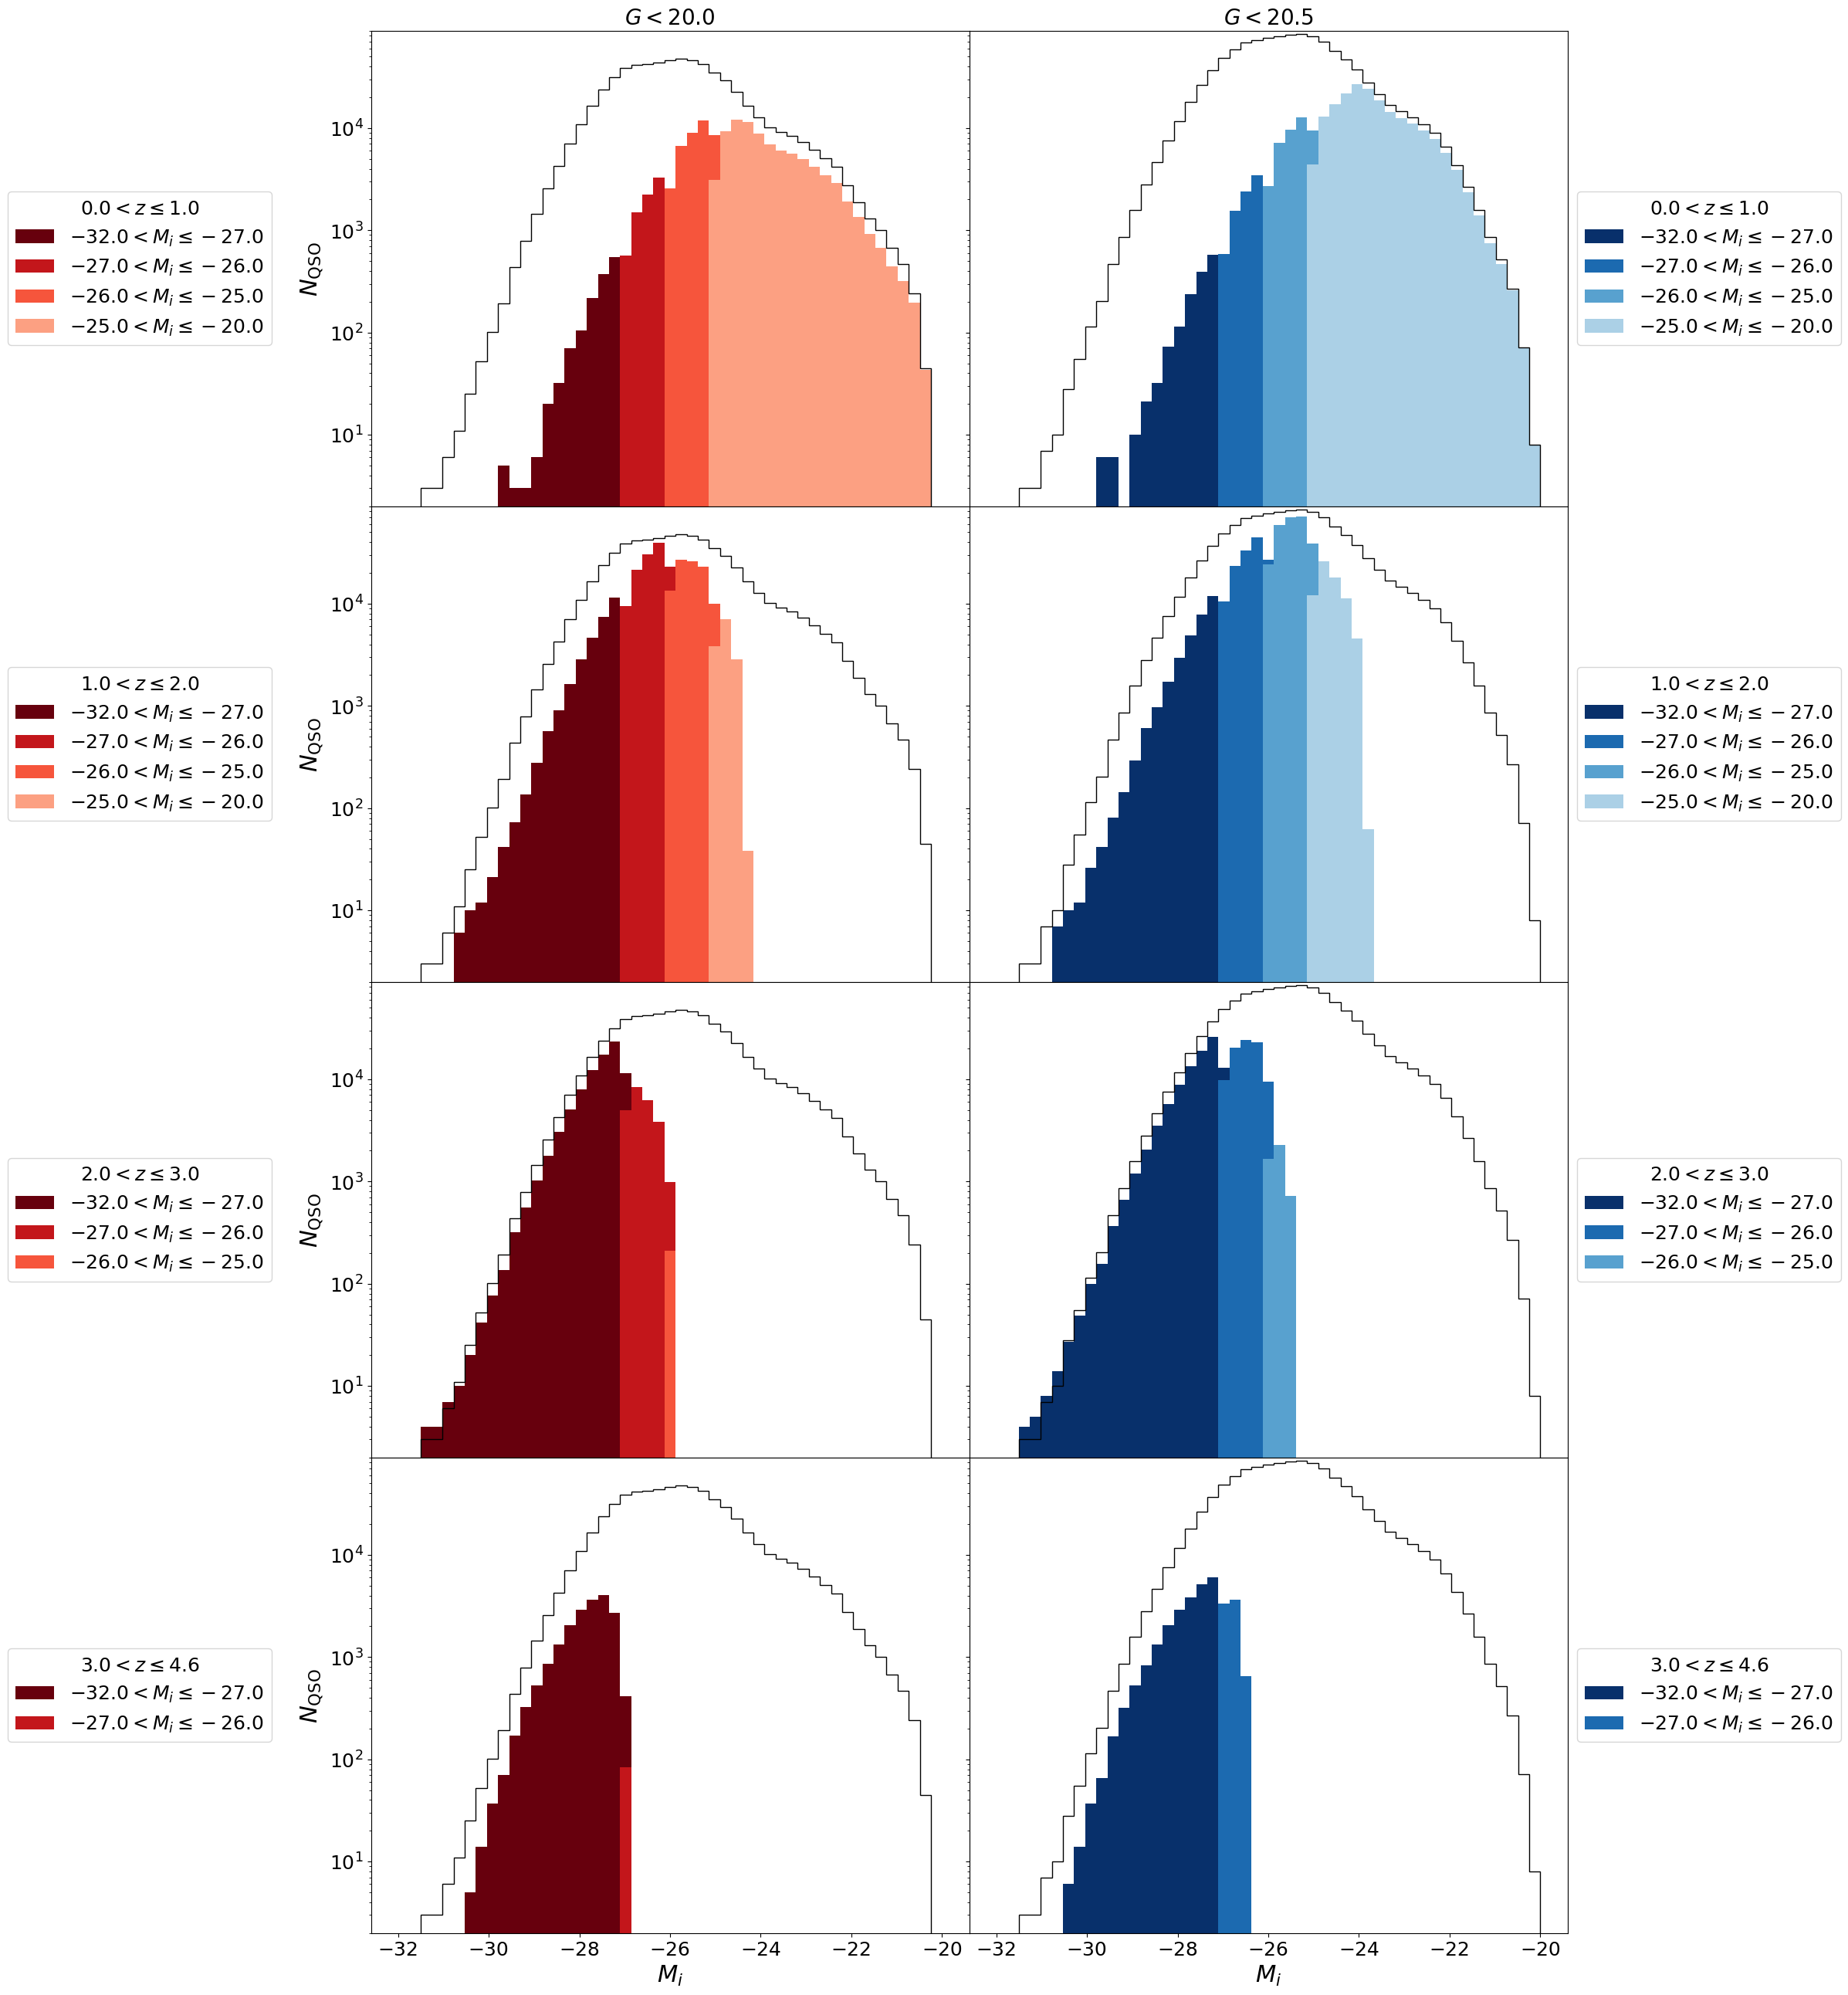

In [42]:
# plot data
bins = np.linspace(-32,-20)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]
for i in range(len(G_array)):

    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')
        
        for k in L_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None])
                ax1.hist(tab_datahi_mask_zbin0['M_i'], label = L_labels[k], bins = bins, color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))

        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if j == 3:
            ax1.set_xlabel('$M_i$')
        else:
            ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5), title = '${}<z\leq{}$'.format(z_bins[j], z_bins[j+1]), title_fontsize = 18)
        ax1.set_ylim(2, 9e4)
        if i>0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.00              1730 vs 1730
G20.0_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.00              36305 vs 36311
G20.0_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0: 0.11              84624 vs 95423
G20.0_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0: 0.06              19140 vs 20368
G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.00              9911 vs 9911
G20.0_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0: 0.07              124034 vs 132662
G20.0_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0: 0.65              24570 vs 69636
G20.0_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0: 0.00              83 vs 83
G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.01              38900 vs 39167
G20.0_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0: 0.43              99299 vs 173186
G20.0_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0: 0.00              211 vs 211
G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.43              84985 vs 149969
G20.0_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0: 

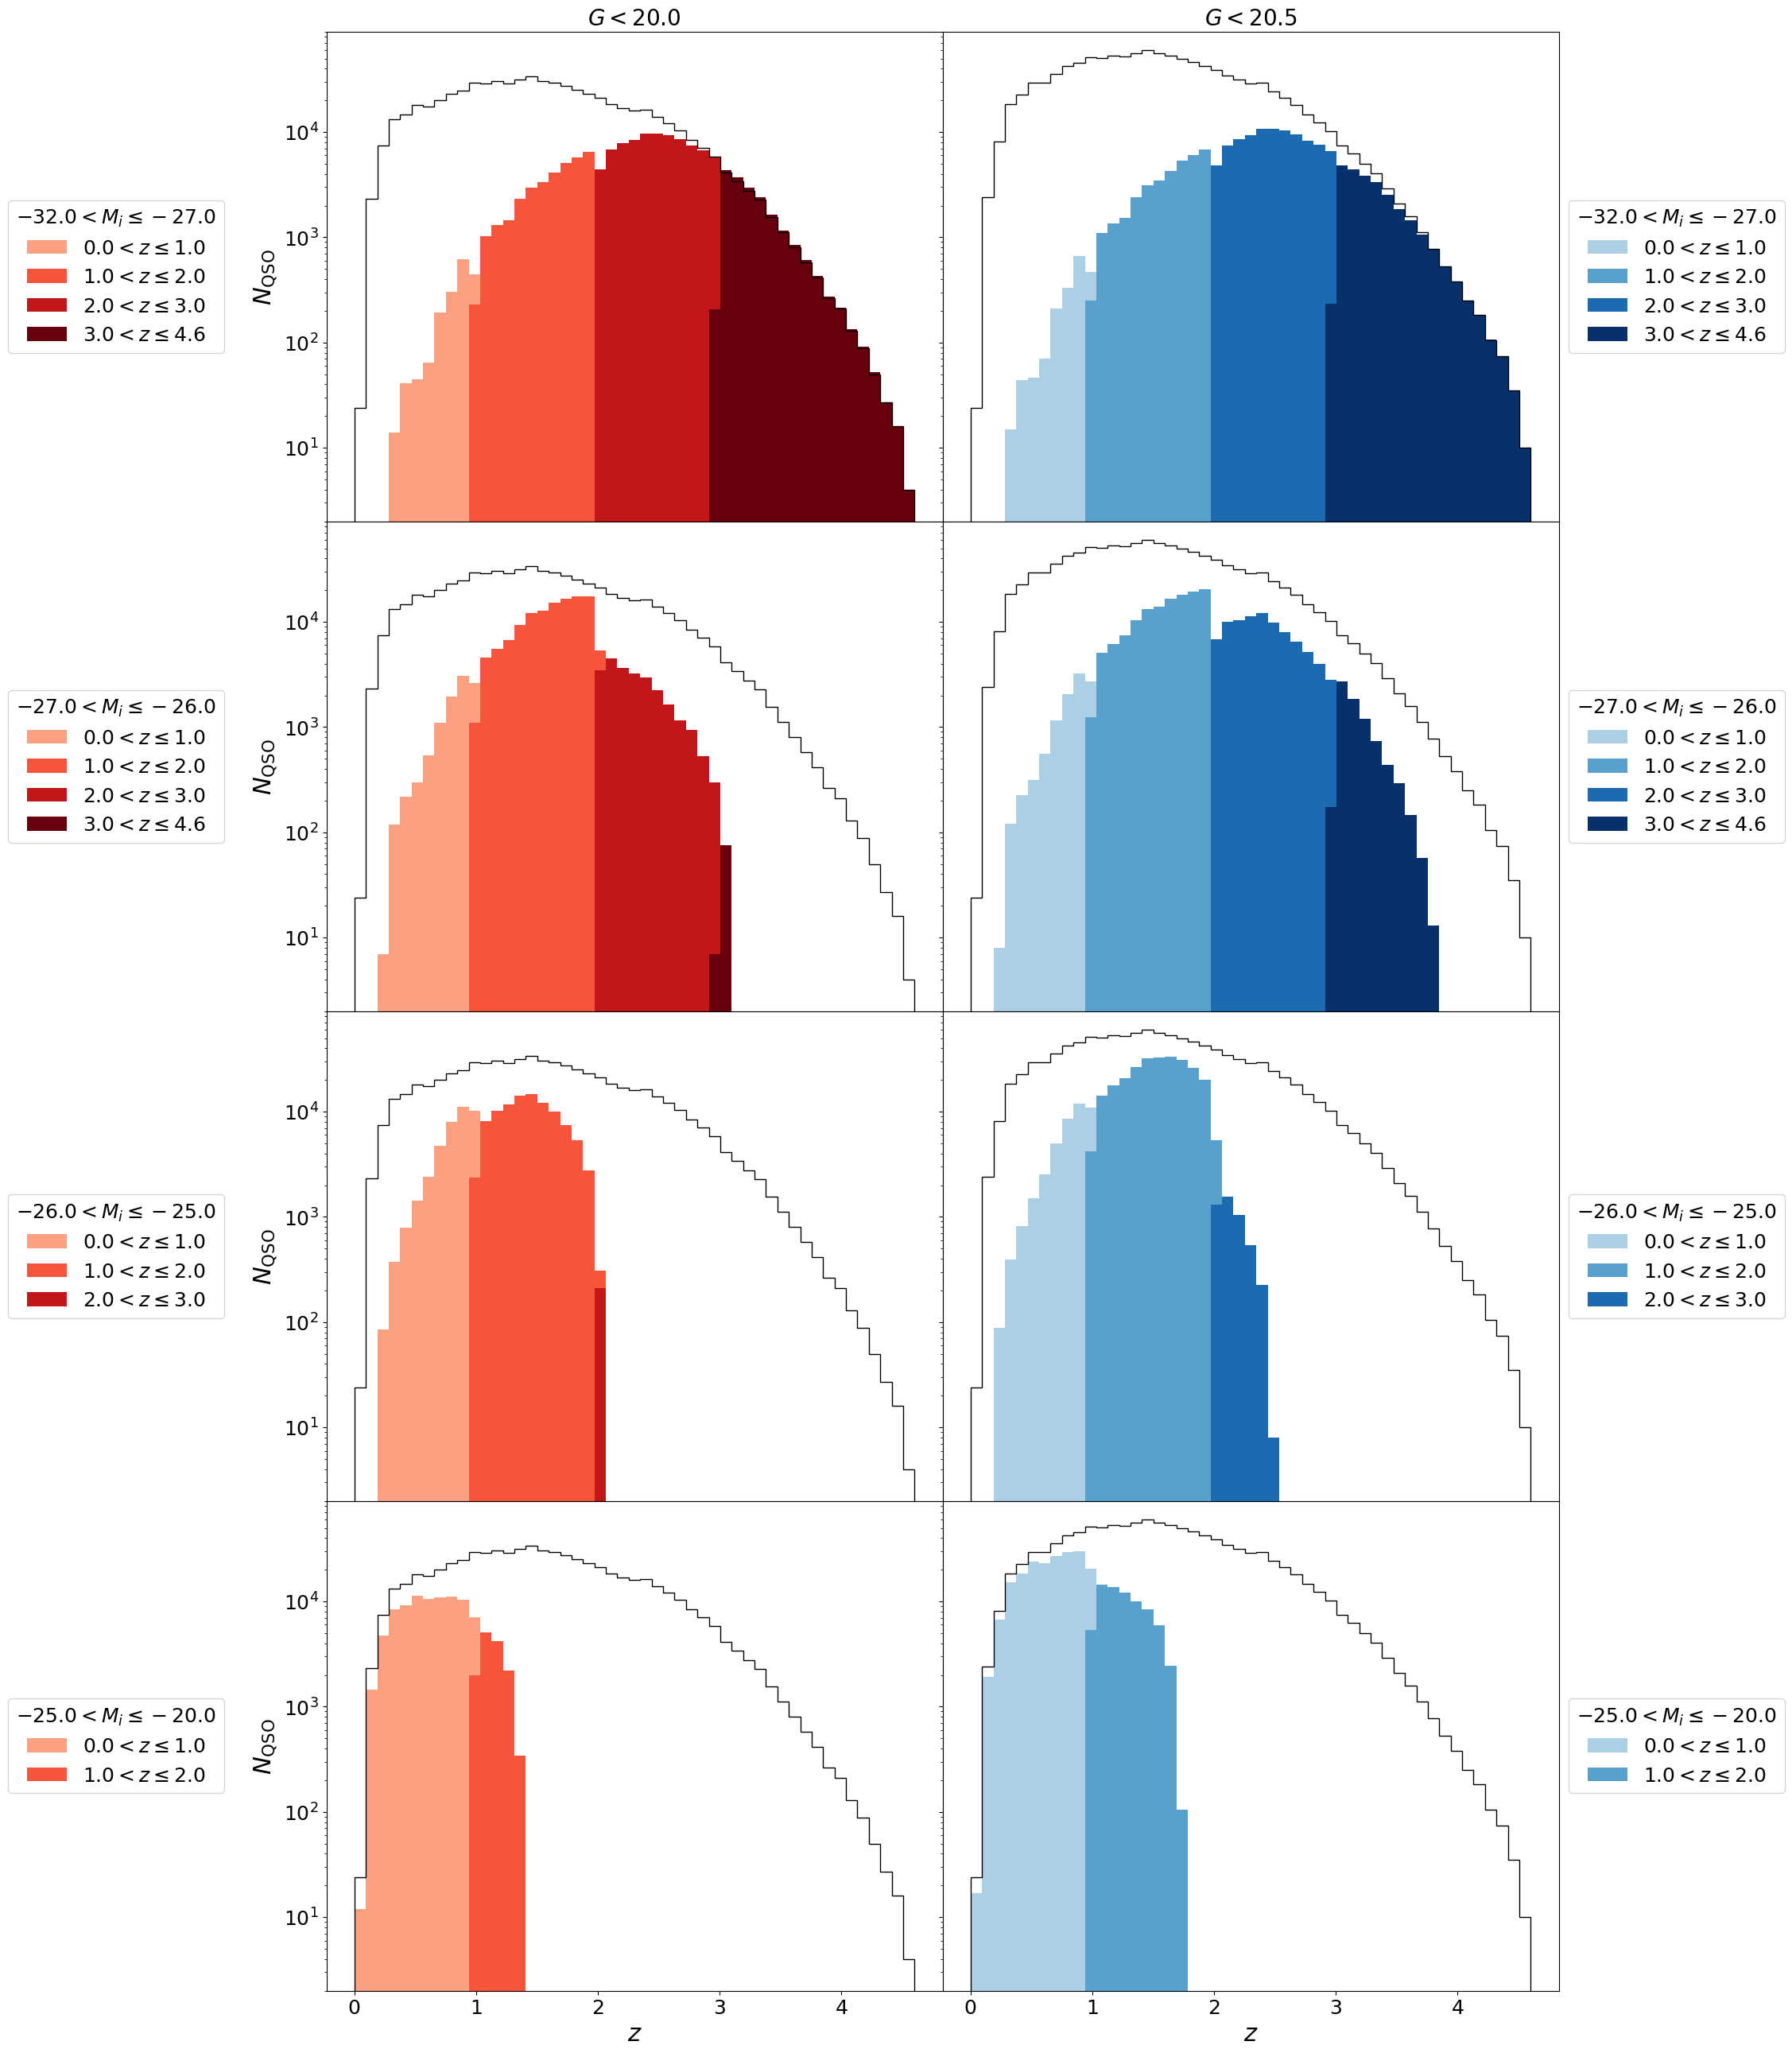

In [50]:
# plot data
bins = np.linspace(0, 4.6)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]
for i in range(len(G_array)):

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        ax1.hist(tabs[i]['redshift_quaia'], bins=bins, histtype = 'step', color='black')
        
        for k in z_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [k,j], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None])
                ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = z_labels[k], bins = bins, color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))

        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if j == 3:
            ax1.set_xlabel('$z$')
        else:
            ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5), title = '${}<M_i\leq{}$'.format(L_bins[j], L_bins[j+1]), title_fontsize = 18)
        ax1.set_ylim(2, 9e4)
        if i>0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

## $\xi(s)$

In [55]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [67]:
# plot data
# bins = np.linspace(-32,-20)
cf = {G_lo: [], G_hi: []}

# # plot!
for i in range(len(G_array)):
    
    for j in z_array:
        
        cf_L = []
        for k in L_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None])
                cf_L.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        cf[G_array[i]].append(cf_L)

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.00              1730 vs 1730


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.00              9911 vs 9911


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.01              38900 vs 39167


...

G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0: 0.10              25880 vs 28856


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0: 0.00              7600 vs 7600


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


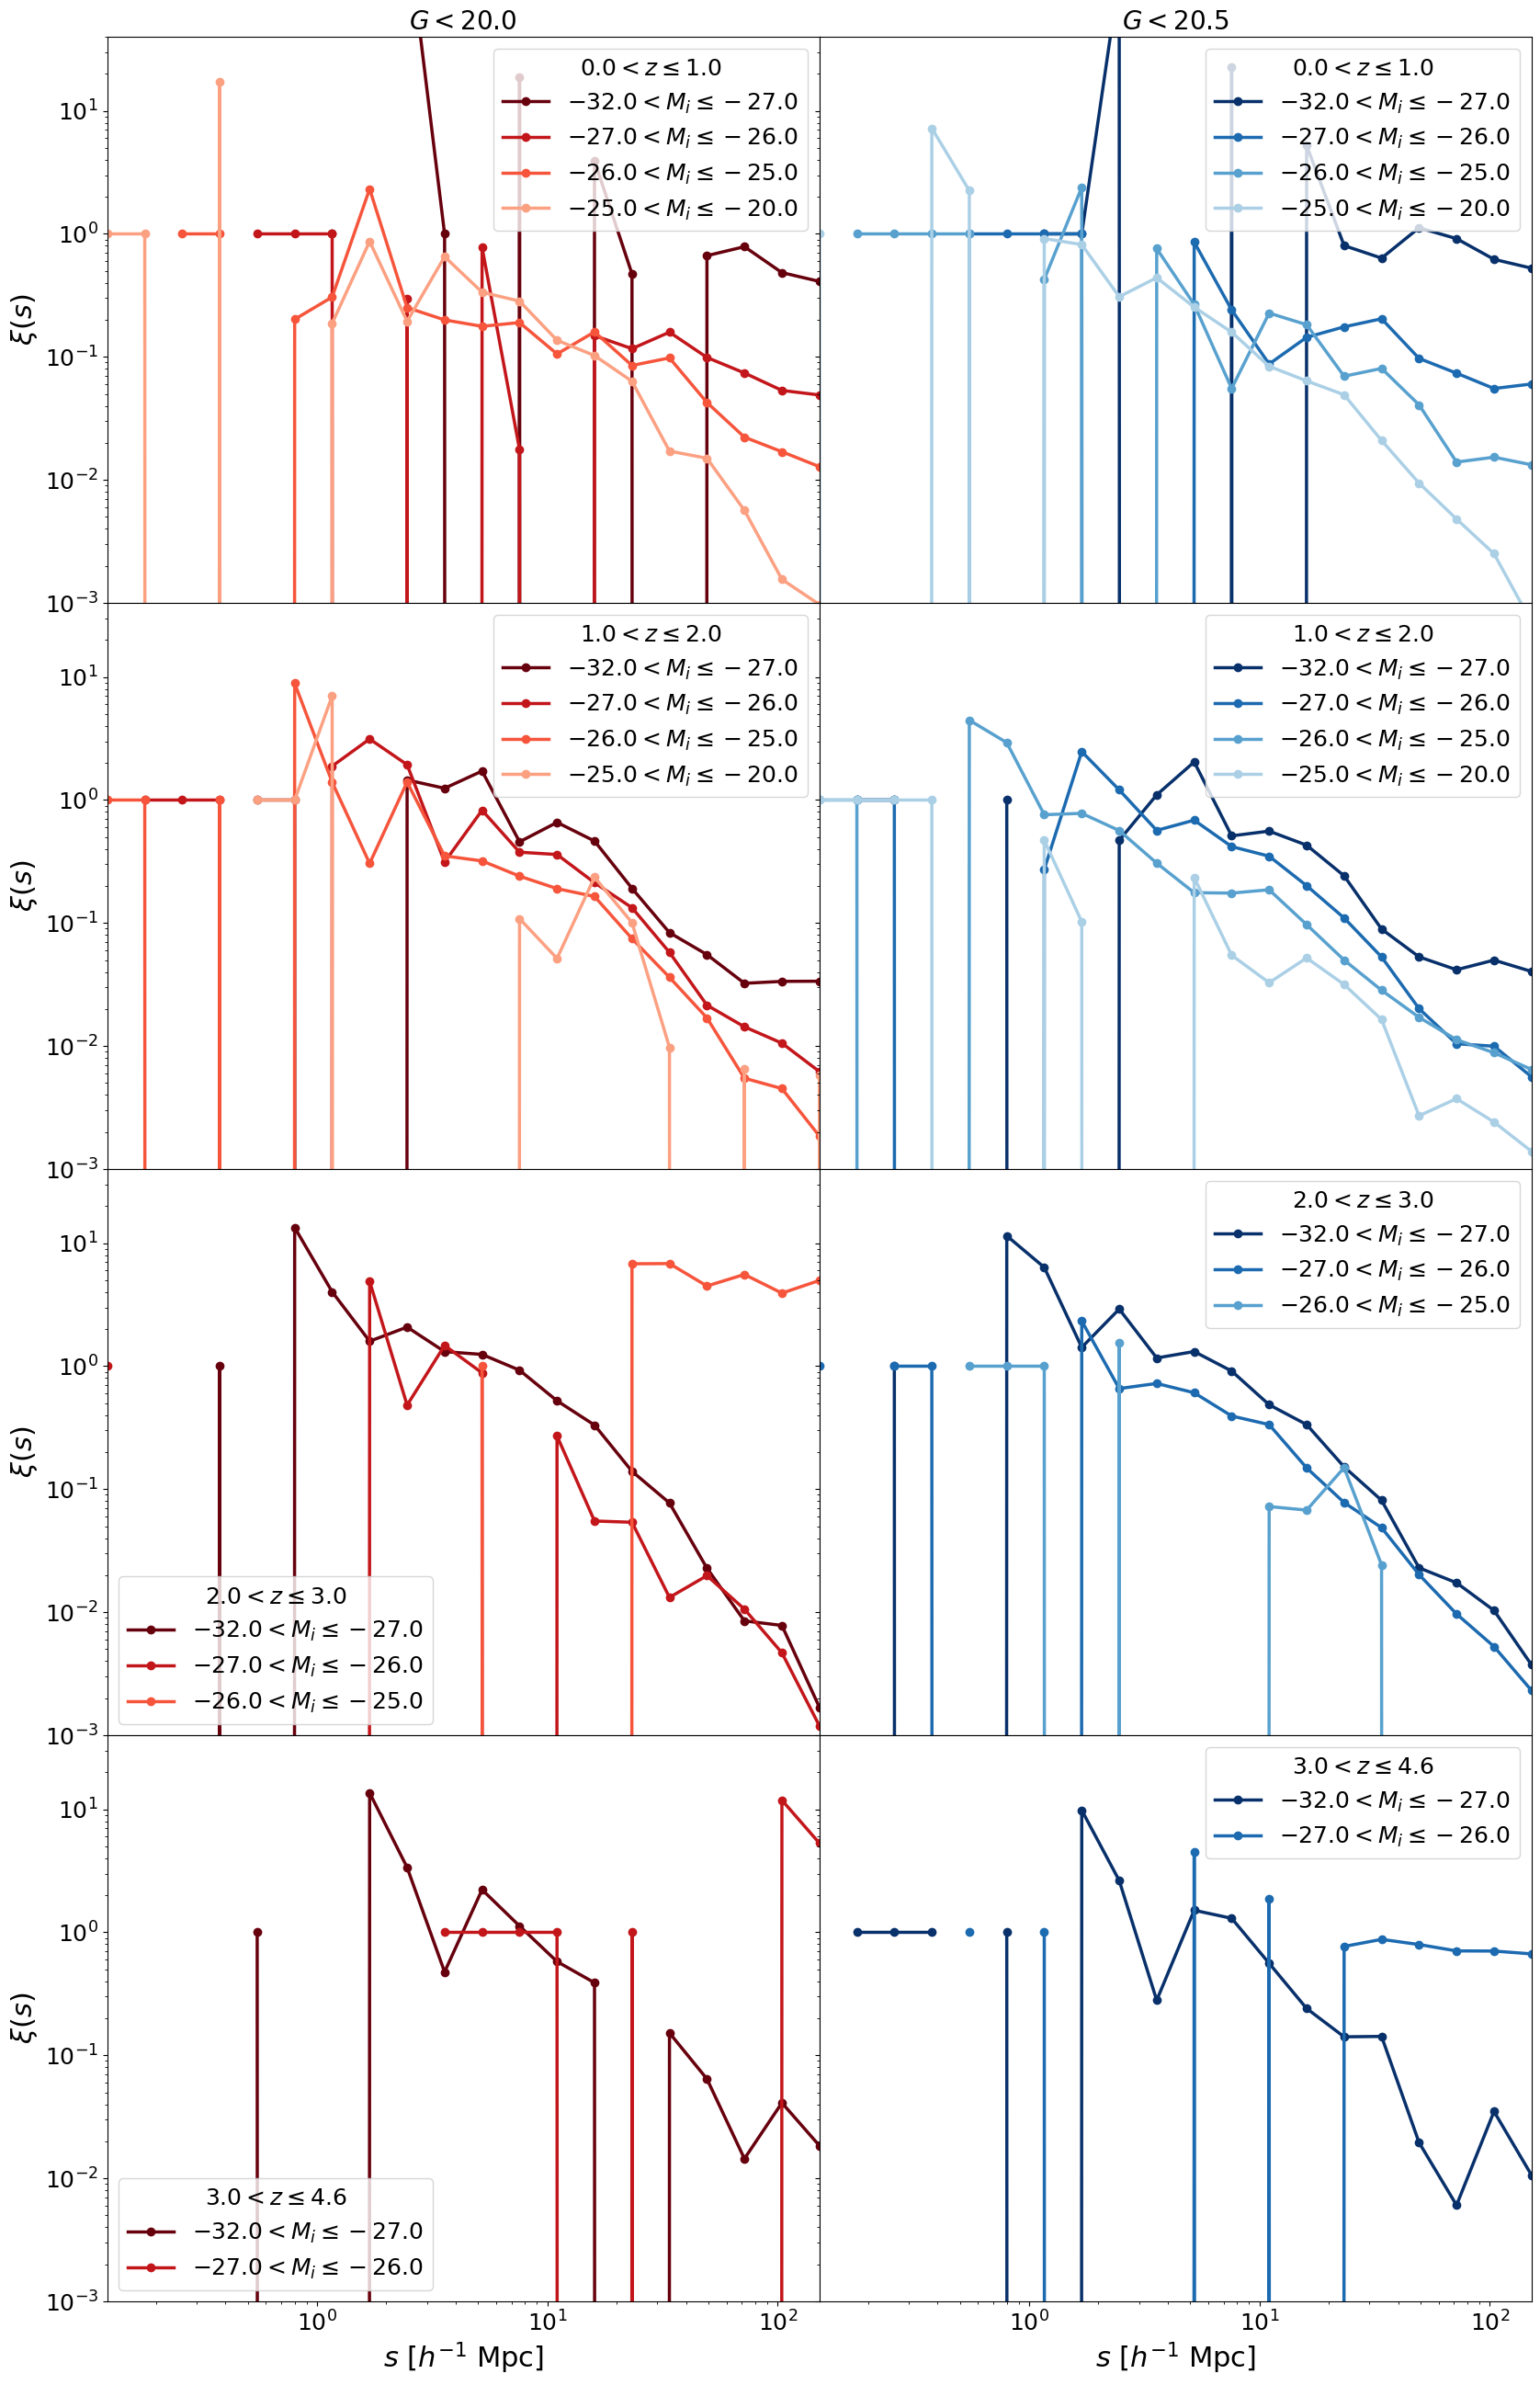

In [75]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
                ax1.plot(quaia.recenter(rbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-3, 4e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        if j == 3:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


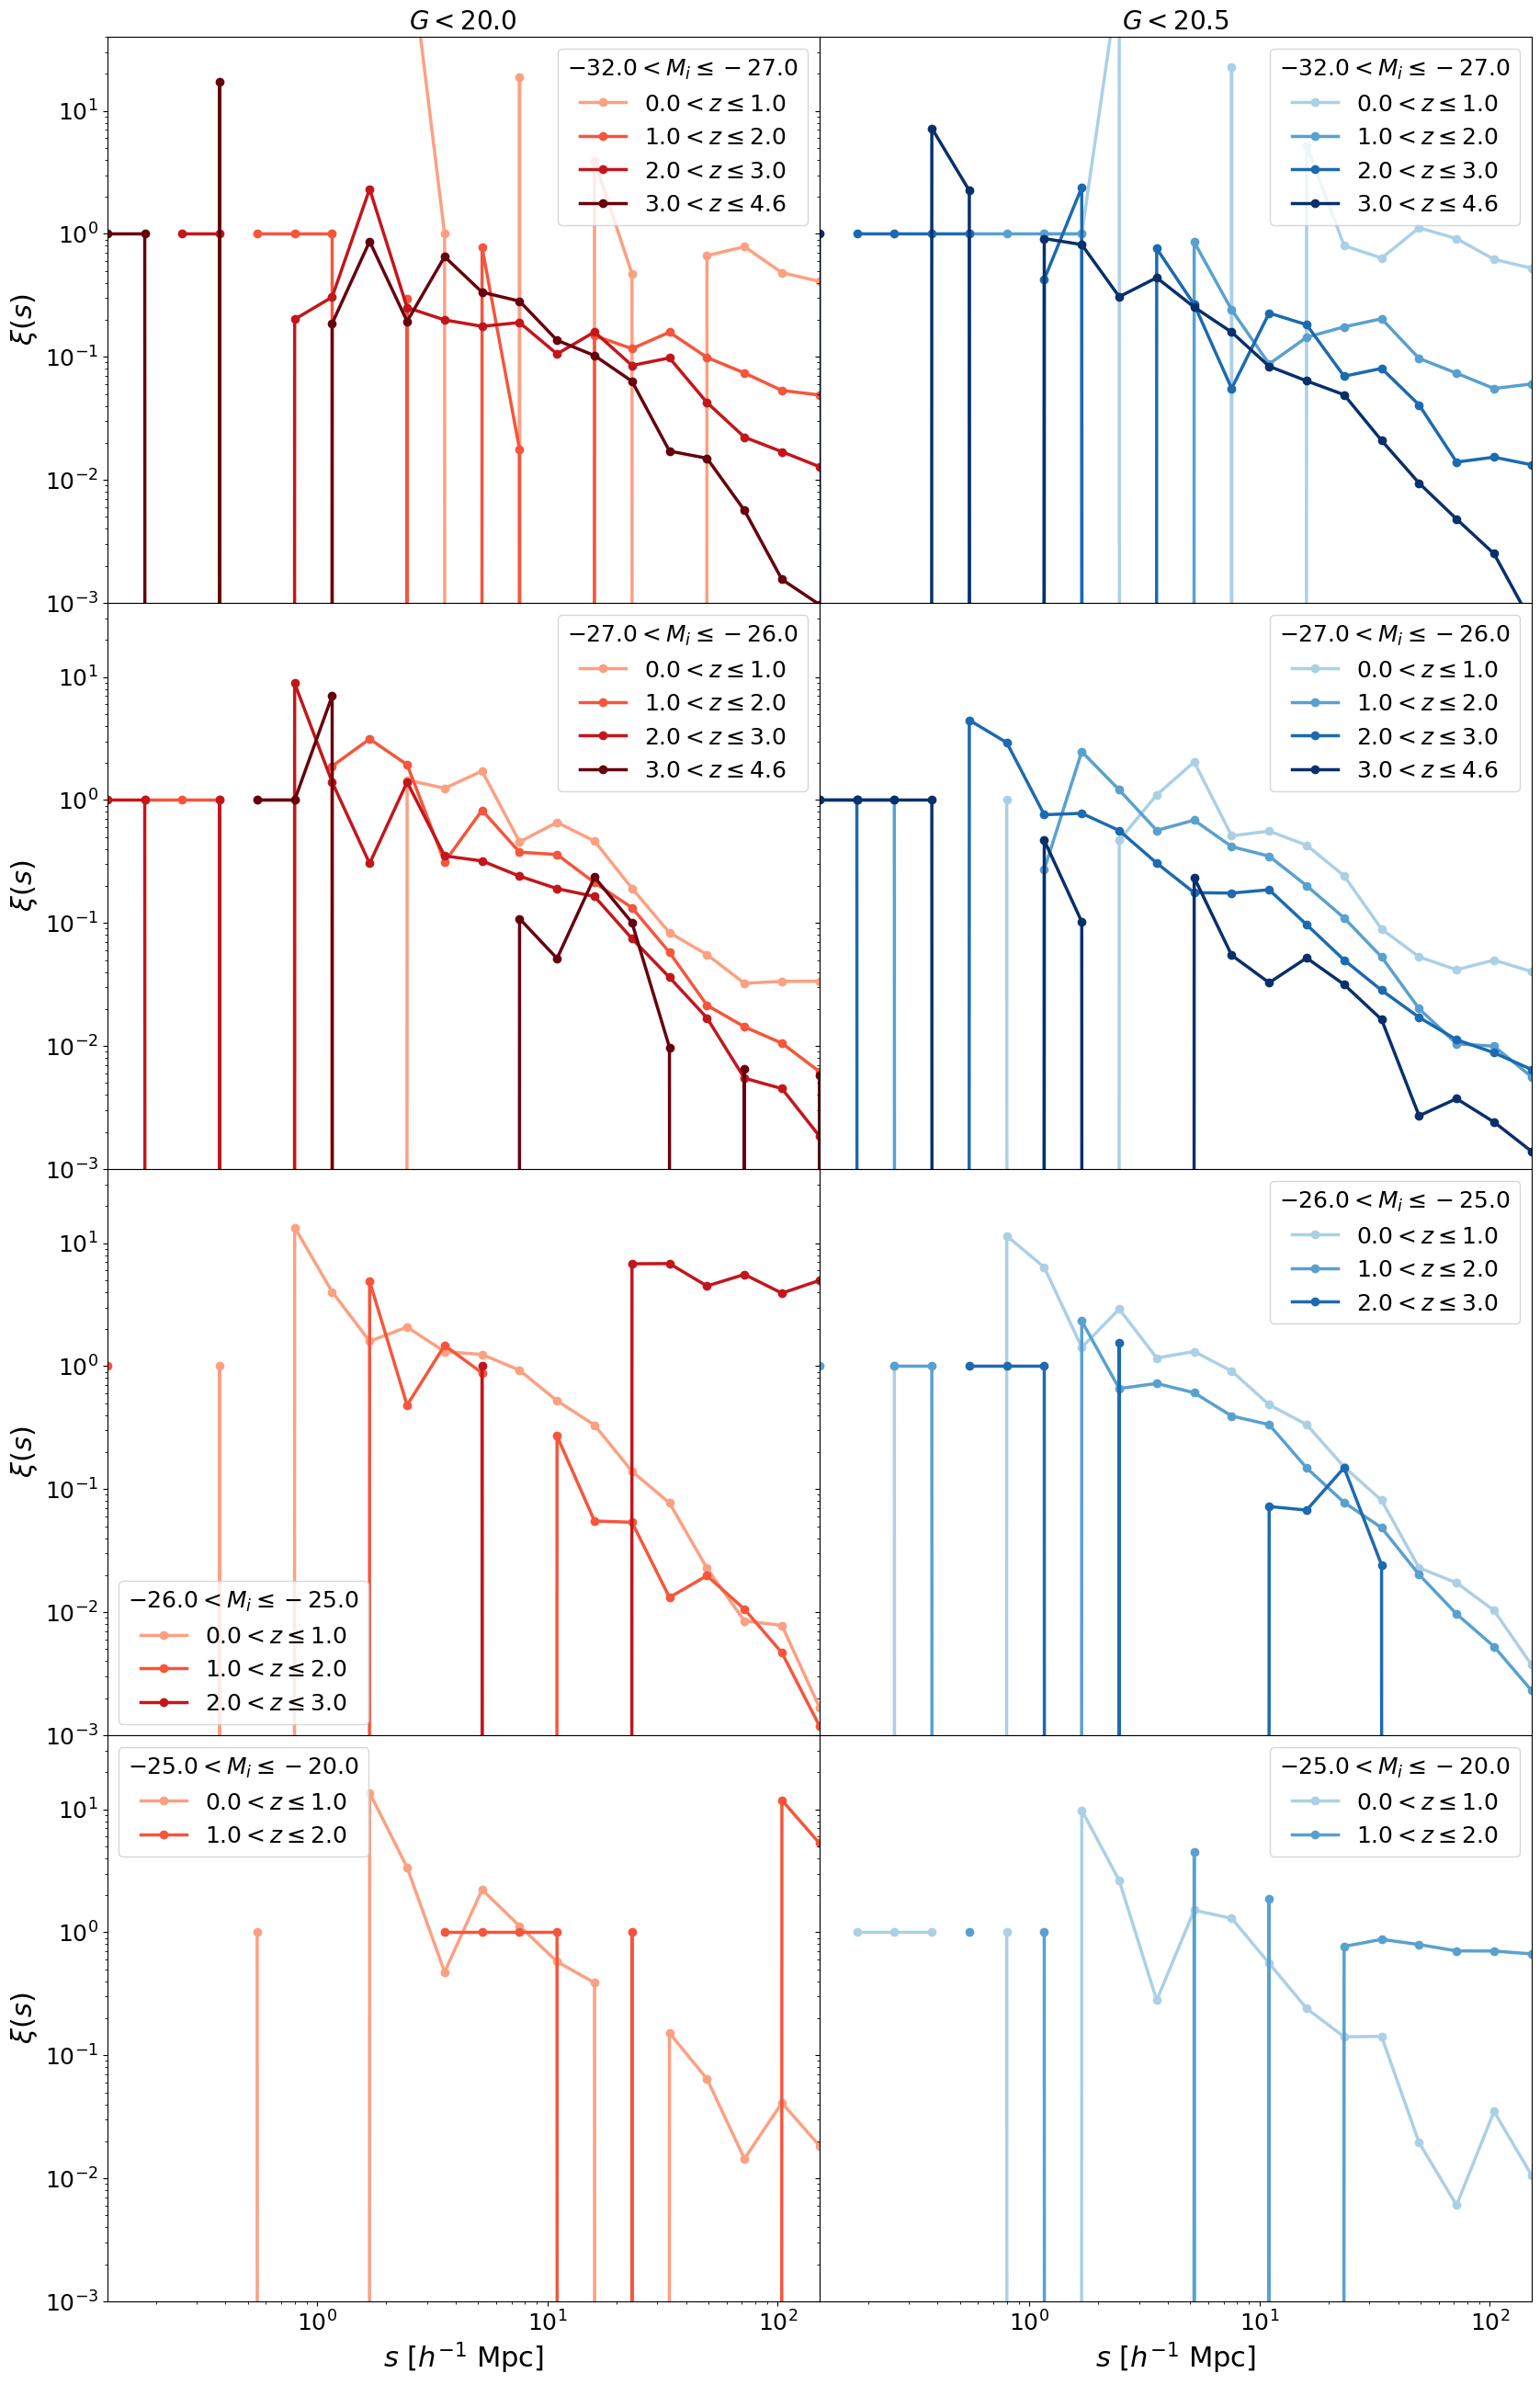

In [79]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
                ax1.plot(quaia.recenter(rbins), cf[G_array[i]][j][k], label = z_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-3, 4e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        if j == 3:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


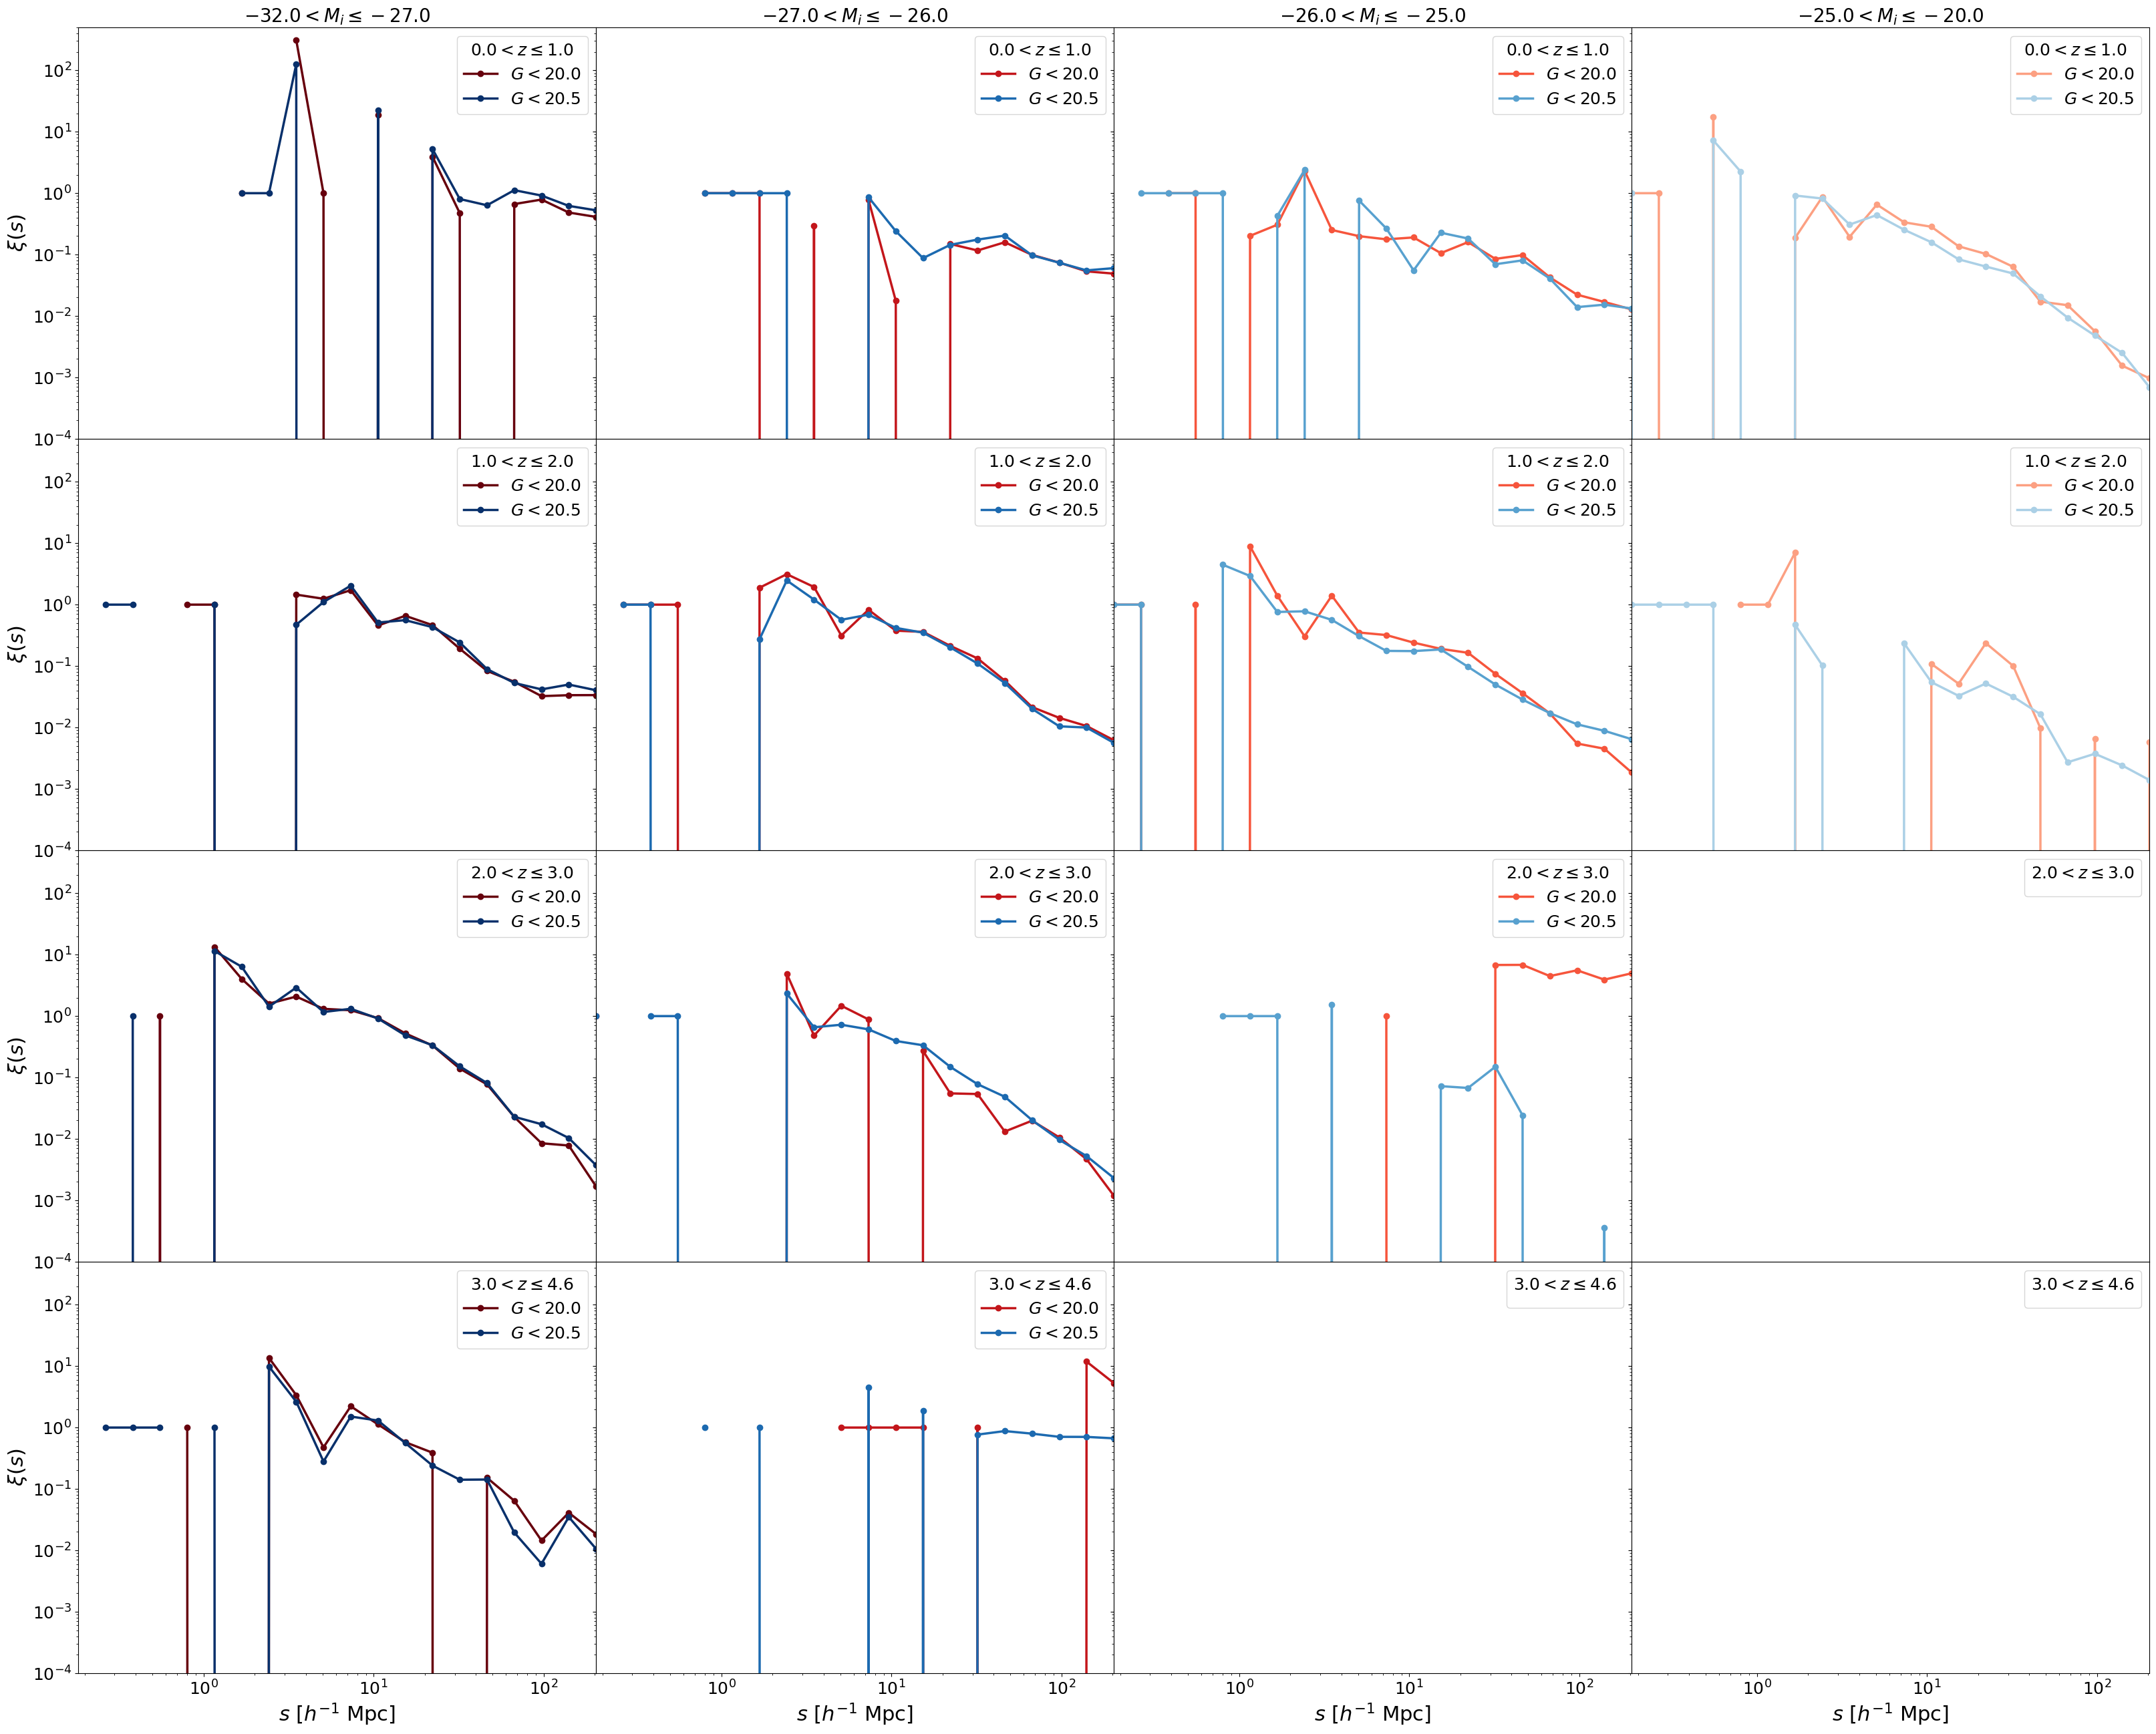

In [98]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(rbins), cf[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 5e2)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

## $w_p(r_p)$

In [94]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [95]:
pimax = 80 # 40 # 5000.0 # 40.0

In [111]:
# plot data
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for j in z_array:
        
        wp_L = []
        rpavg_L = []
        for k in L_array:
            
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None])
                
                wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins, nbins = nbins, pimax = pimax)
                wp_L.append(wp_datahi_zbin0)
                rpavg_L.append(rpavg_datahi_zbin0)
                
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        wp[G].append(wp_L)
        rpavg[G].append(rpavg_L)
                

G20.5_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.00              1860 vs 1860


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.00              10412 vs 10412


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:683: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:683: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


G20.5_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.00              41735 vs 41931


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0: 0.00              7600 vs 7600


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:683: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


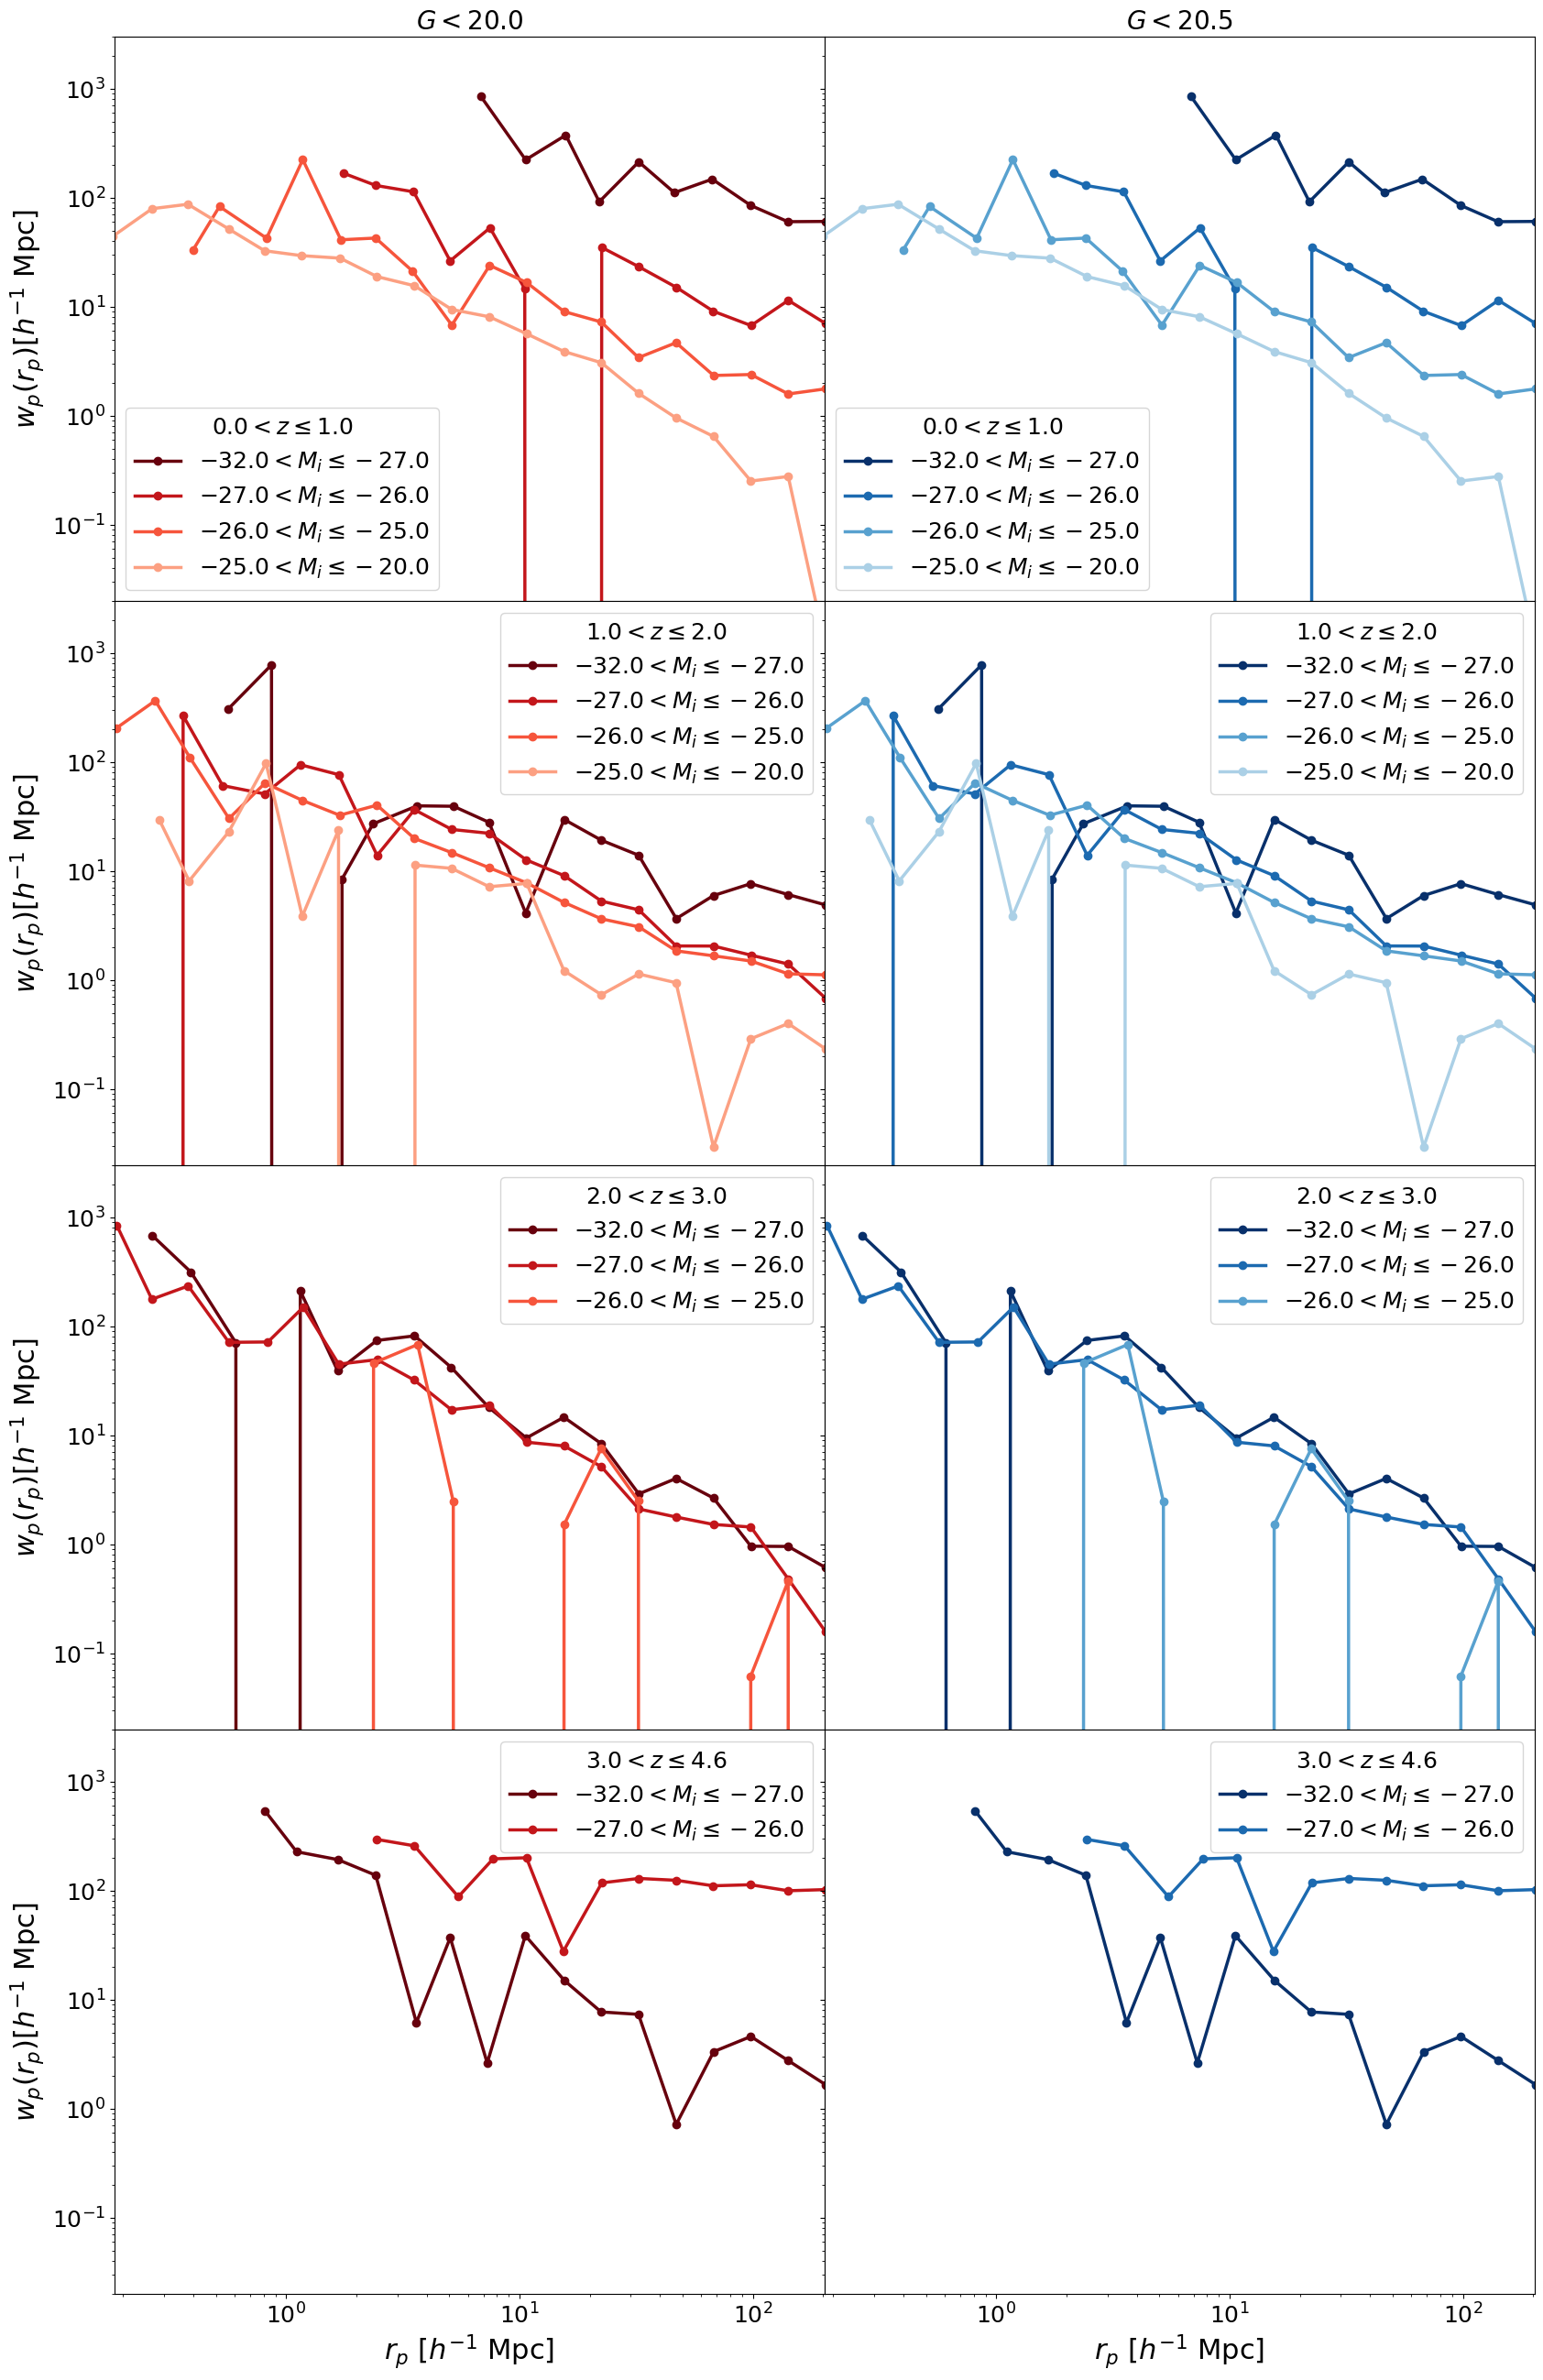

In [112]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


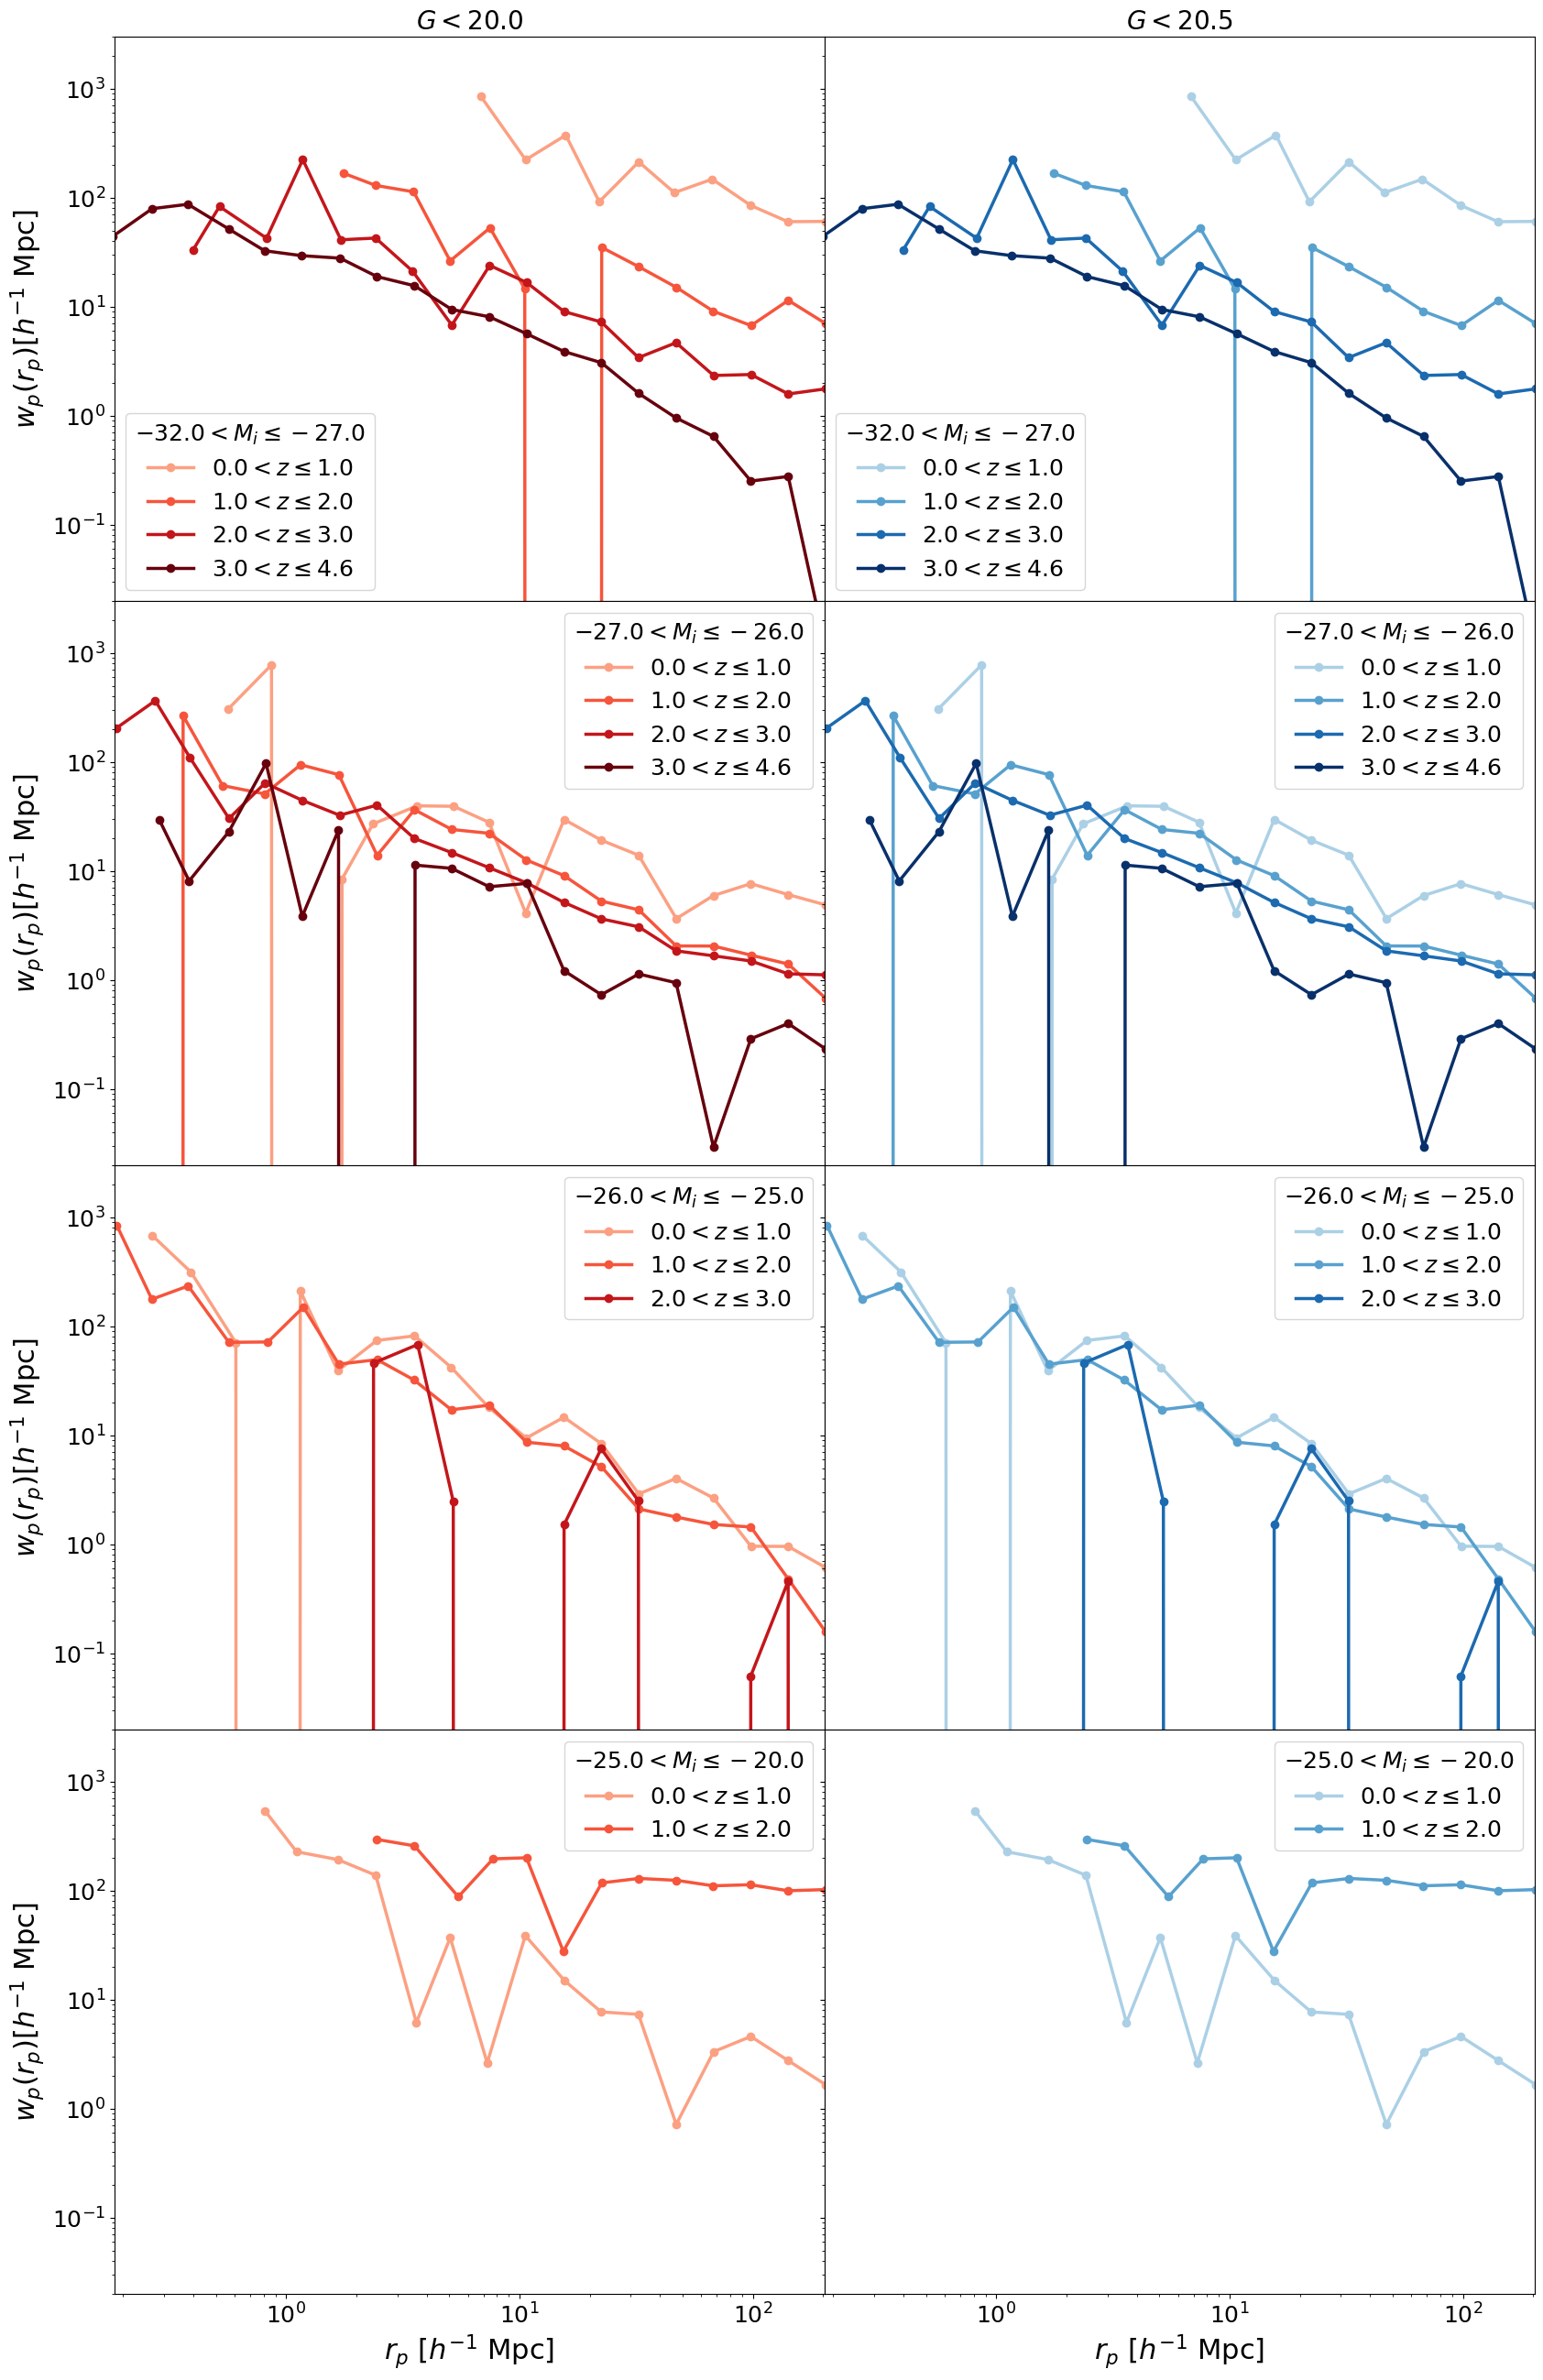

In [116]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k], label = z_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

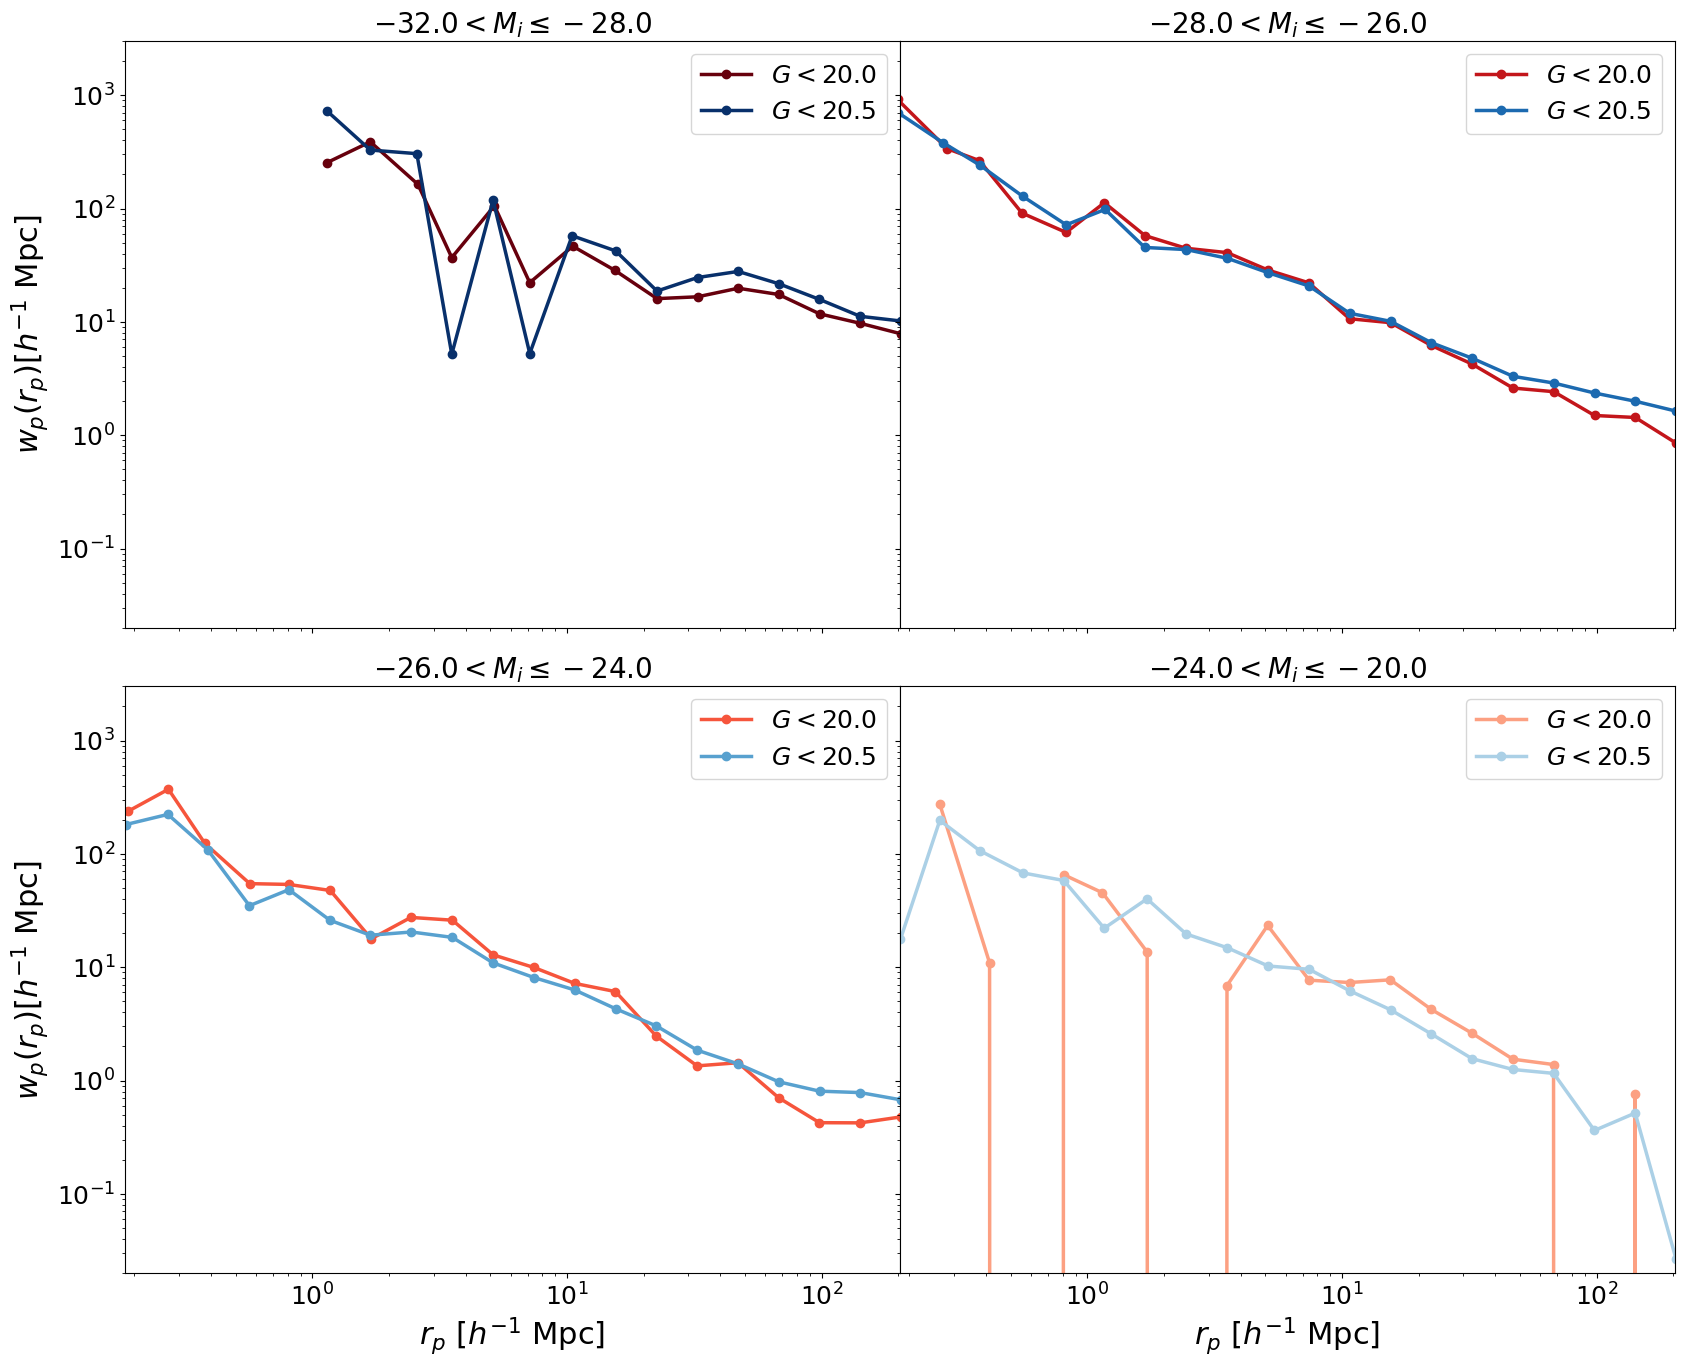

In [28]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-2, 3e3)
    ax1.legend()
    if Lbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])
    if Lbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

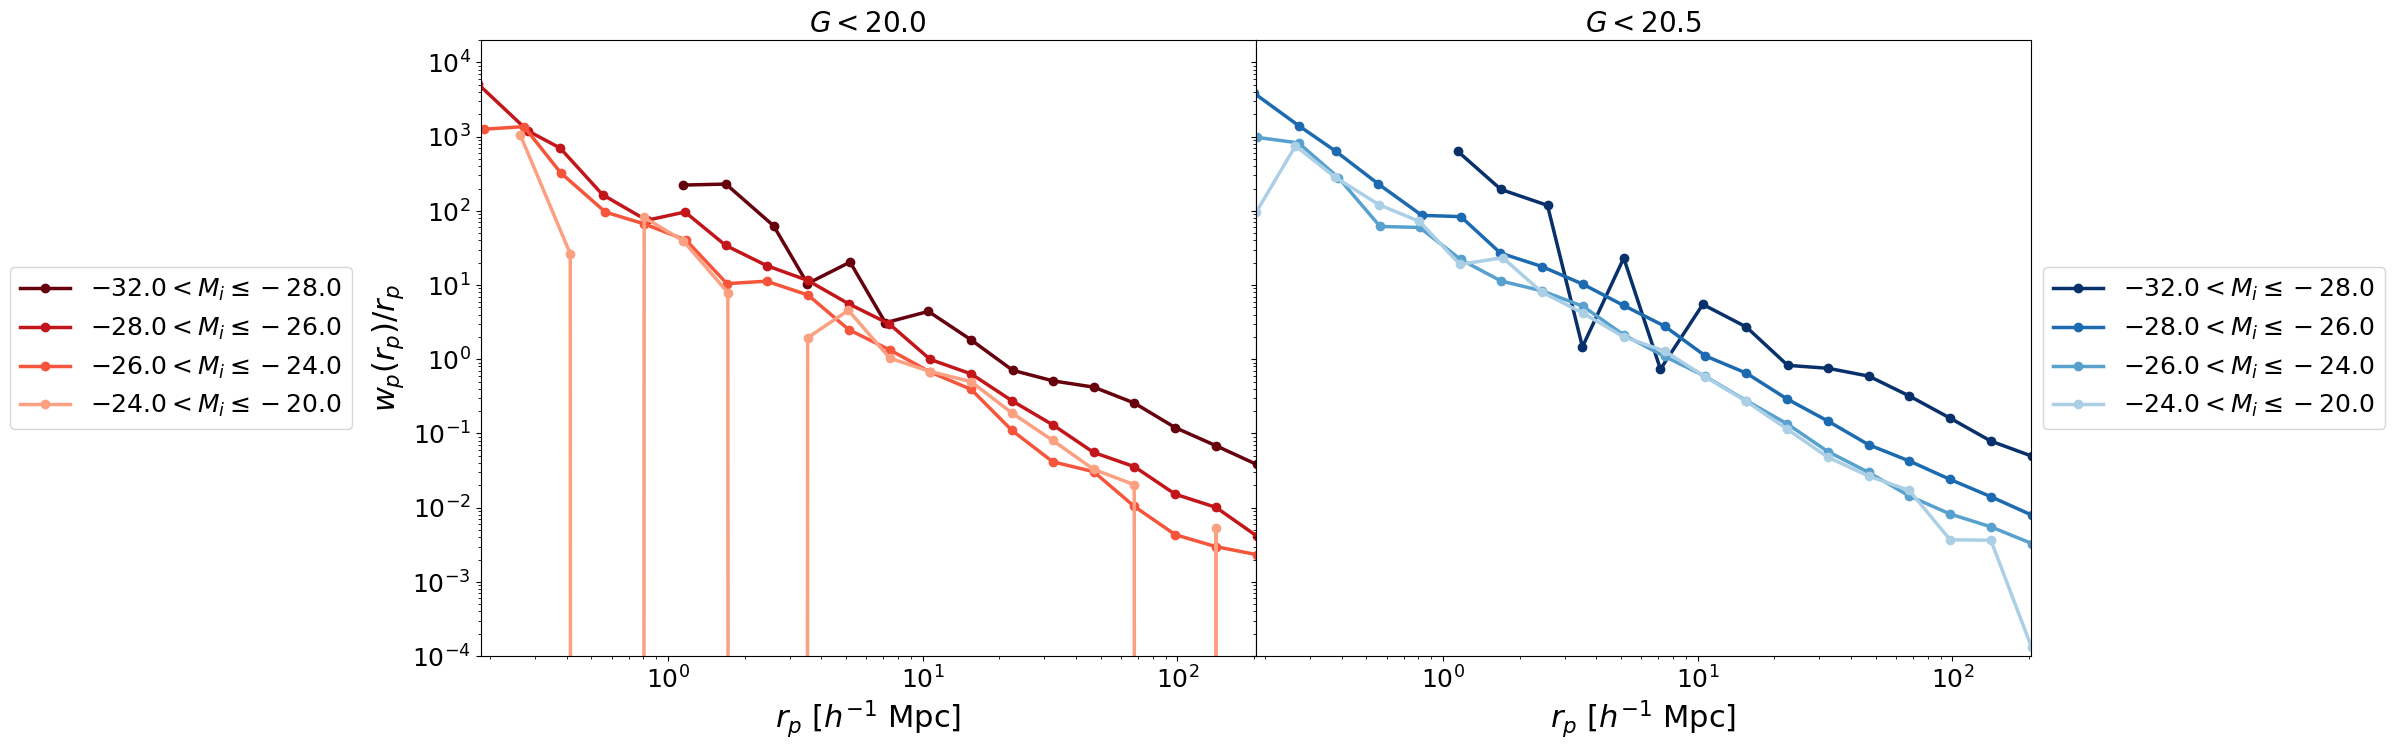

In [29]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

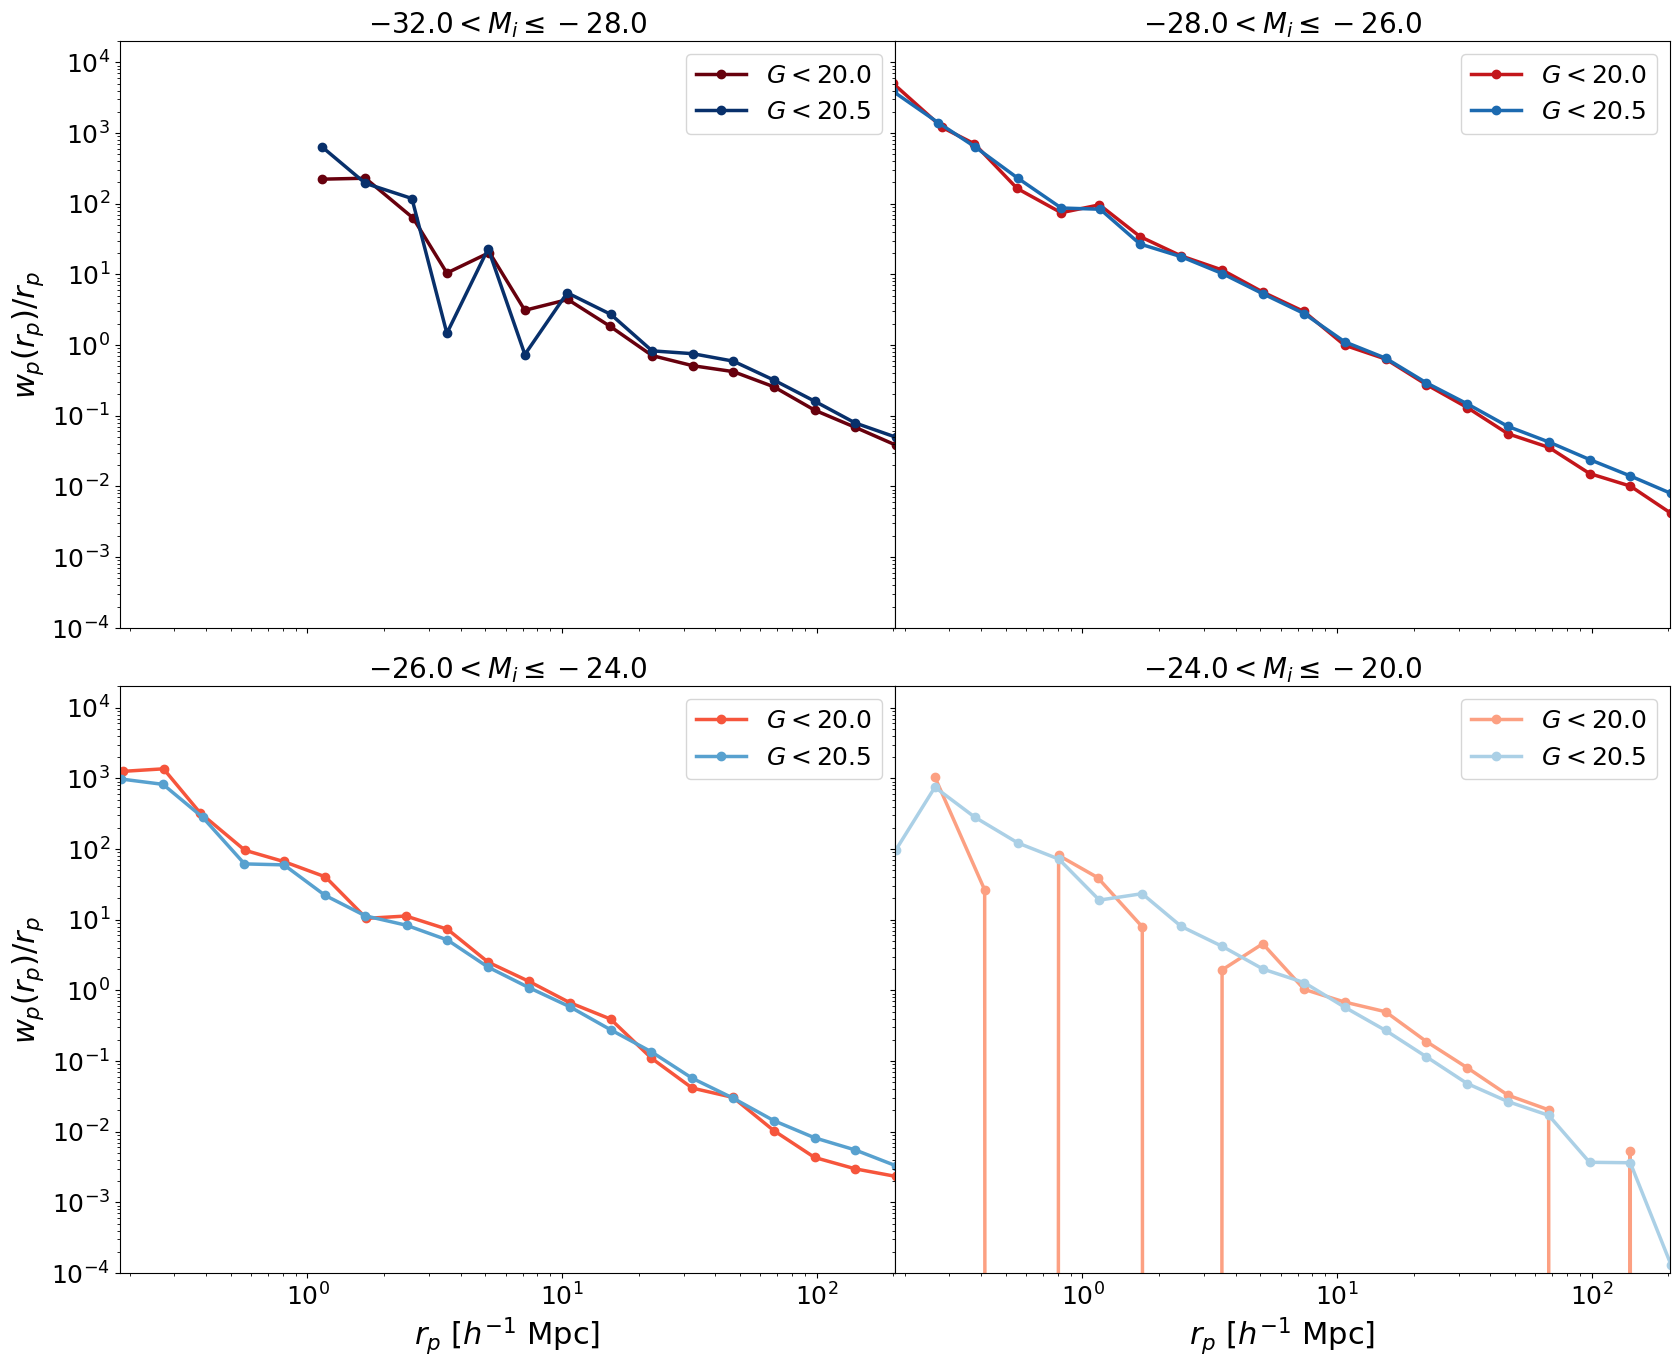

In [30]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

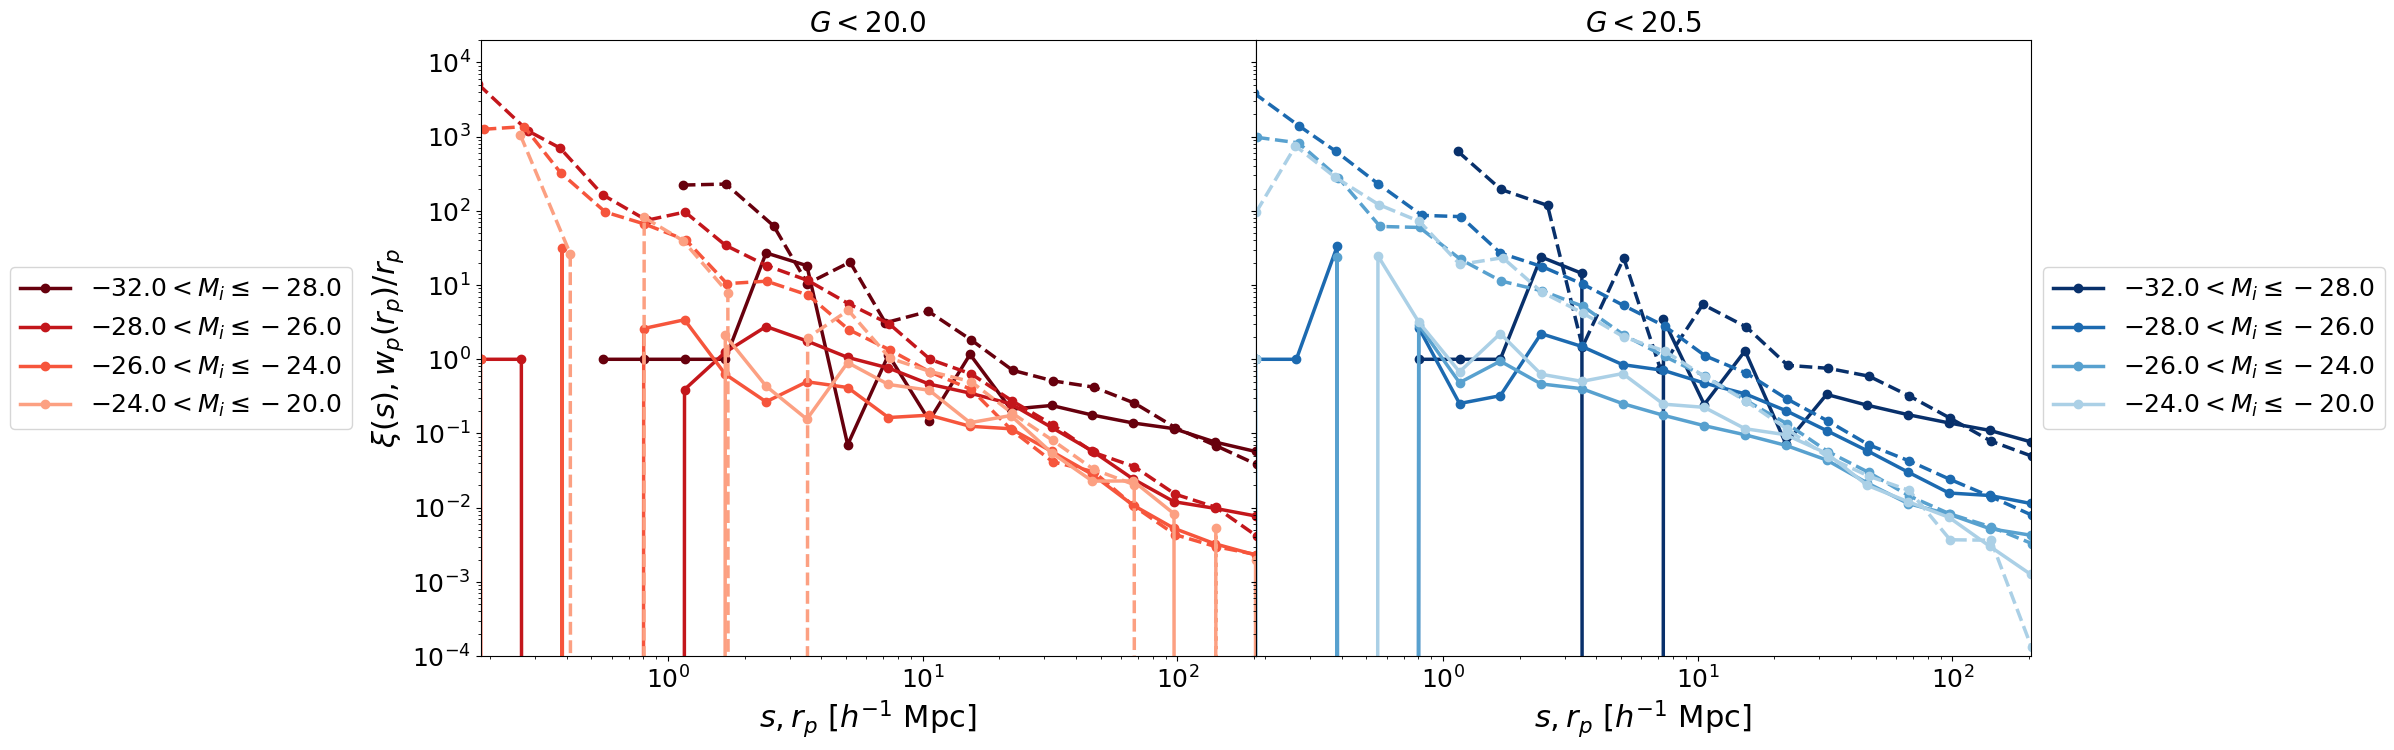

In [31]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin], linestyle = '--')
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

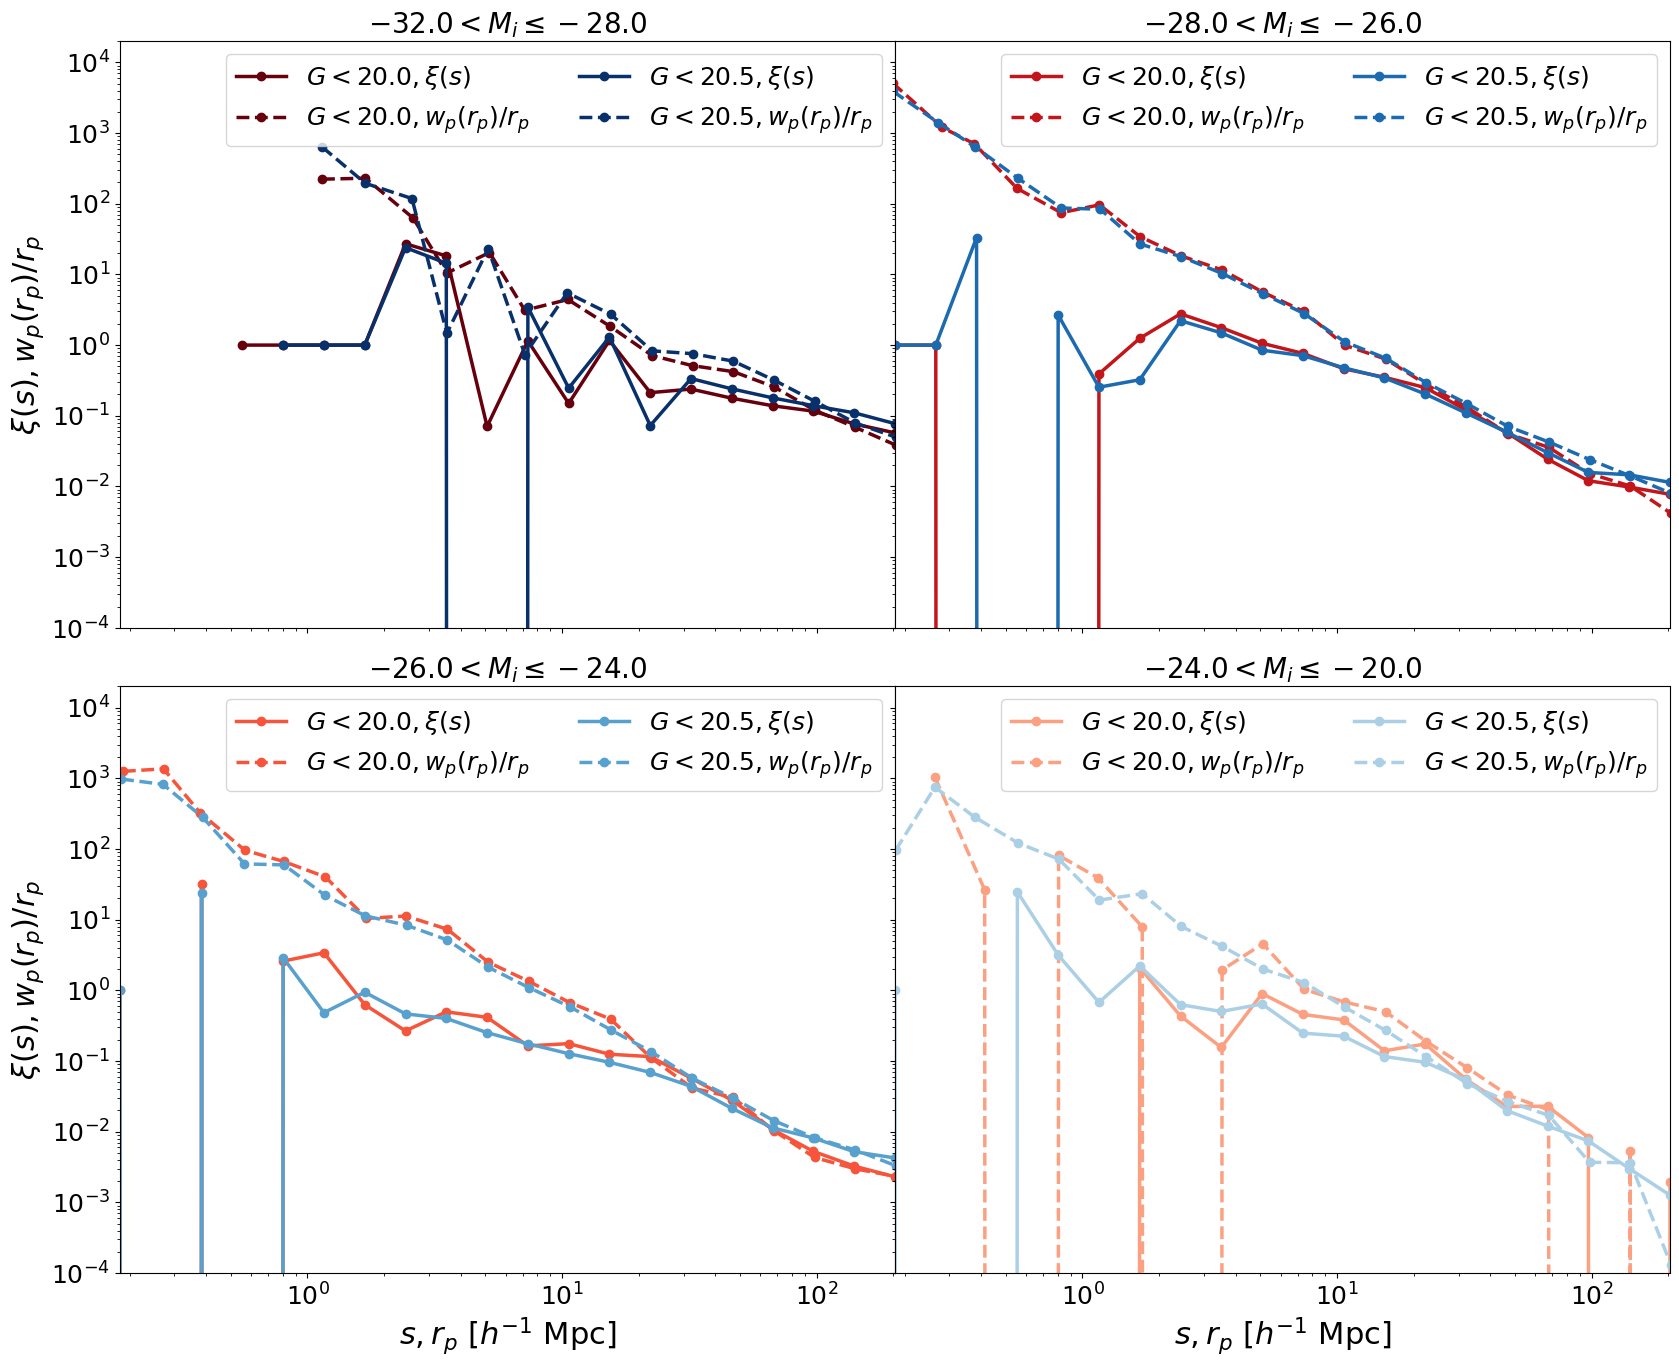

In [32]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}, \\xi(s)$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}, w_p(r_p)/r_p$'.format(G), linewidth = 2.5, marker = 'o', linestyle = '--',
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(ncol = 2)
    if Lbin%2==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>1:
        ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

## $w(\theta)$

In [19]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [20]:
# plot data
wtheta = {G_lo: [], G_hi: []}
for G in G_array:

    for Lbin in L_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, _, _, _ = quaia.make_bins(G, Lbin, True, 'L', bins = L_bins, fac_rand = 25, method = 'minmax',
                                                                                tab_gcat_type = 'data', z = False)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-28.0


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 0.020152
DR: 0.6983600000000001
RR: 5.272931
_G20.0_Lmin-28.0Lmax-26.0
DD: 0.899842
DR: 54.069469
RR: 658.903737
_G20.0_Lmin-26.0Lmax-24.0
DD: 0.6108709999999999
DR: 39.535459
RR: 453.3075
_G20.0_Lmin-24.0Lmax-20.0
DD: 0.01765
DR: 0.776548
RR: 7.929638
_G20.5_Lmin-32.0Lmax-28.0
DD: 0.015453999999999999
DR: 0.648524
RR: 5.677962
_G20.5_Lmin-28.0Lmax-26.0
DD: 1.645653
DR: 103.276491
RR: 1300.558472
_G20.5_Lmin-26.0Lmax-24.0
DD: 3.5321249999999997
DR: 194.181042
RR: 2510.734371
_G20.5_Lmin-24.0Lmax-20.0
DD: 0.111719
DR: 6.372896
RR: 72.43221


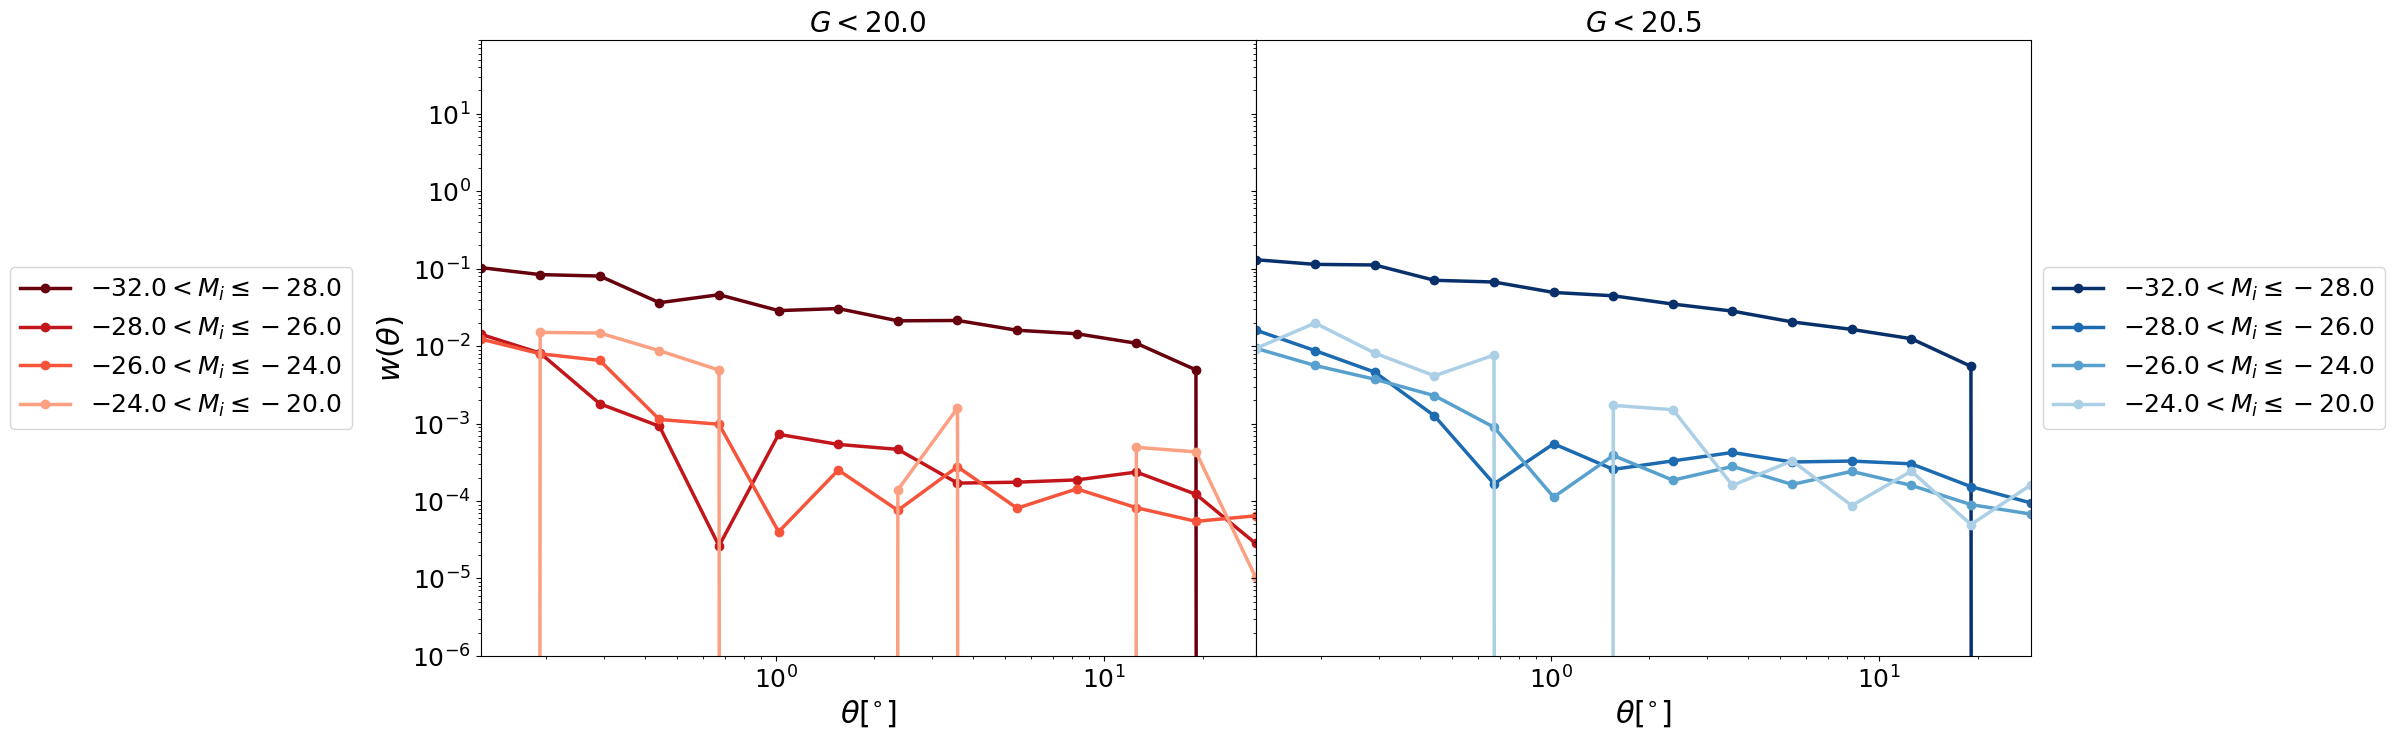

In [24]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):

        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$\theta[^{\circ}]$')
    # if scale == 'log':
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 9e1)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()

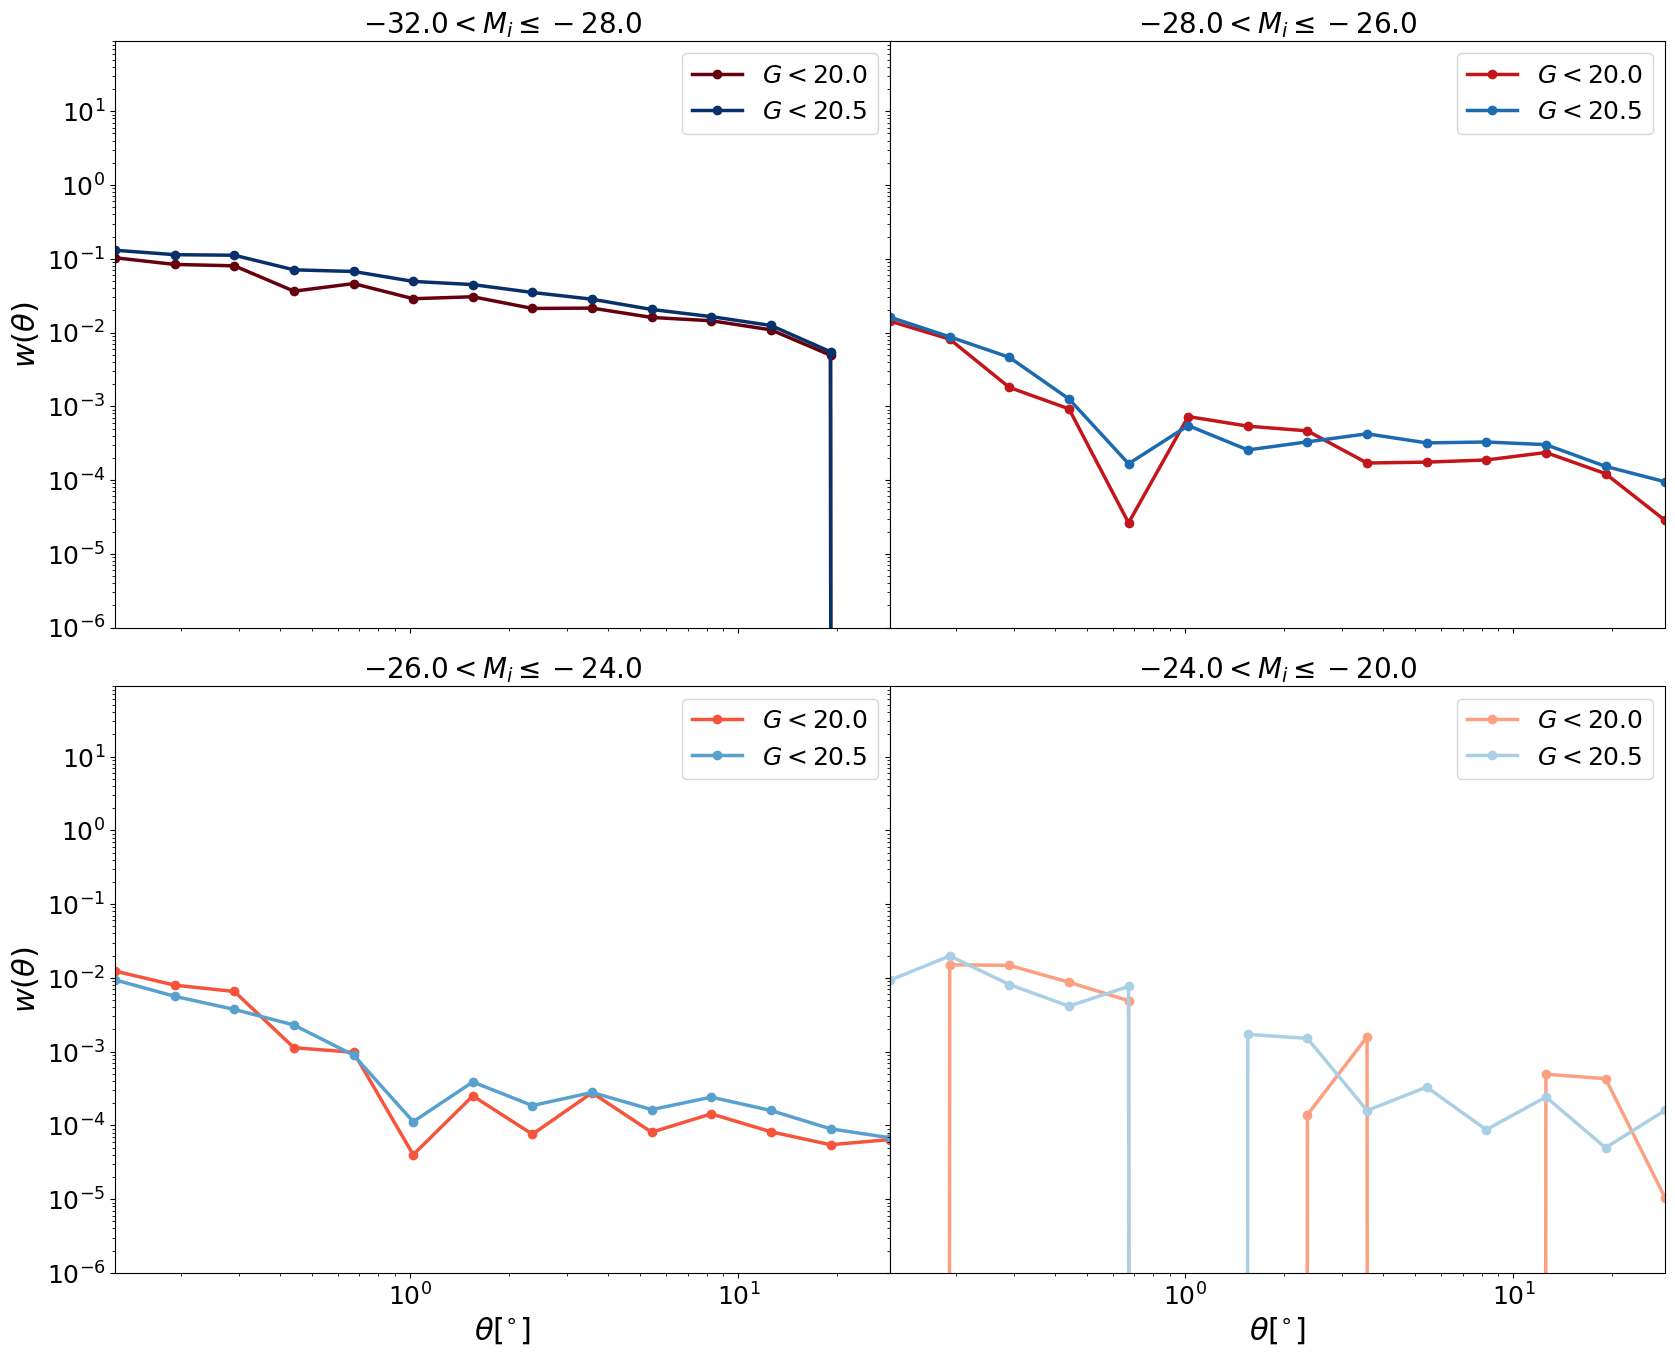

In [26]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(thetabins), wtheta[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    # if scale == 'log':
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 9e1)
    ax1.legend()
    if Lbin>1:
        ax1.set_xlabel(r'$\theta[^{\circ}]$')
    else:
        ax1.set_xticklabels([])
    if Lbin%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()